103.4301408
103
97.10558814235443
96


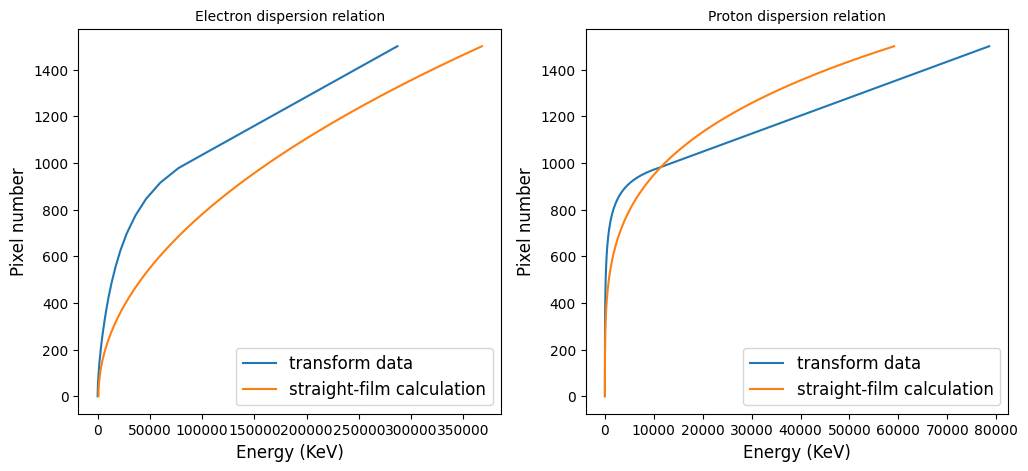

In [87]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

def lineout(array, w1, w2):
    width = np.shape(array)[0]
    length = np.shape(array)[1]
    line_data = array[w2,:]
    for i in range(length):
        line_data[i] = (1/(w2+1-w1))*np.sum(array[w1:w2+1,i])
    return line_data

def theoretical_dispersion(x,A,d):
    energy = A*(x**2+d**2)**2
    return energy

def theoretical_dispersion_relativistic_e(x,a,D):
    m = 9.1*10**-31
    c = 3*10**8
    E = m*c**2
    eV = 1.6*10**-19
    energy = (1/1000)*(1/eV)*0.5*(-E+np.sqrt(E**2+((eV*0.87*c)**2)*(1/D)*((((x-a)**2)+D)**2)))
    return energy

def theoretical_dispersion_relativistic_p(x,a,D):
    m = 1.67*10**-27
    c = 3*10**8
    E = m*c**2
    eV = 1.6*10**-19
    energy = (1/1000)*(1/eV)*0.5*(-E+np.sqrt(E**2+((eV*0.87*c)**2)*(1/D)*((((x-a)**2)+D)**2)))
    return energy

energy_data_protons = np.loadtxt('NEPPS_Dispersion_Protons_087T.txt', skiprows=1)
data_protons = np.loadtxt('Generated_Dispersion.txt', delimiter=',')
energy_data_electrons = np.loadtxt('NEPPS_Dispersion_Electrons_087T.txt', skiprows=1)

def linear_fit(x,m,c):
    y = m*x+c
    return y

def transform_electron_axis(x, R):
    energy = np.zeros(len(x))
    start = energy_data_electrons[-1,1]
    print(start)
    for i in range(len(x)):
        if np.abs((1/R)*x[i]-start) == np.min(np.abs((1/R)*x-start)):
            index = i
    print(index)
    energy[0:index] = np.interp((1/R)*x[0:index],np.array(energy_data_electrons[:,1]),np.array(energy_data_electrons[:,0]))

    deltax = energy_data_electrons[-1,1]-energy_data_electrons[-2,1]

    deltaE = energy_data_electrons[-1,0]-energy_data_electrons[-2,0]

    grad = deltaE/deltax

    intercept = energy_data_electrons[-1,0] - grad*energy_data_electrons[-1,1]

    energy[index:] = linear_fit((1/R)*x[index:], grad, intercept)

    return energy

def transform_proton_axis(x, R):
    energy = np.zeros(len(x))
    start = data_protons[1,-1]
    print(start)
    for i in range(len(x)):
        if np.abs((1/R)*x[i]-start) == np.min(np.abs((1/R)*x-start)):
            index = i
    print(index)
    energy[0:index] = np.interp((1/R)*x[0:index],np.array(data_protons[1]),np.array(data_protons[0]))

    deltax = data_protons[1,-1]-data_protons[1,-2]

    deltaE = data_protons[0,-1]-data_protons[0,-2]

    grad = deltaE/deltax

    intercept = data_protons[0,-1] - grad*data_protons[1,-1]

    energy[index:] = linear_fit((1/R)*x[index:], grad, intercept)

    return energy

def find_index(axis,start,end):
    for i in range(len(axis)):
        if np.abs(axis[i]-start) == np.min(np.abs(axis-start)):
            start_i = i

    for i in range(len(axis)):
        if np.abs(axis[i]-end) == np.min(np.abs(axis-end)):
            end_i = i
    return start_i, end_i


r = 10

x_axis = np.linspace(0,1500,150)


fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(transform_electron_axis(x_axis,10),x_axis,label='transform data')
axs[0].plot(theoretical_dispersion_relativistic_e((1/10000)*x_axis,0.0,0.008**2),x_axis,label='straight-film calculation')
axs[0].set_xlabel("Energy (KeV)")
#axs[0].set_xlim(0,500)
#axs[0].set_ylim(0,200)
axs[0].set_ylabel("Pixel number")
axs[0].set_title("Electron dispersion relation")
axs[0].legend()

axs[1].plot(transform_proton_axis(x_axis,10),x_axis,label='transform data')
axs[1].plot(theoretical_dispersion_relativistic_p((1/10000)*x_axis,0.001,0.012**2),x_axis,label='straight-film calculation')
axs[1].set_xlabel("Energy (KeV)")
axs[1].set_ylabel("Pixel number")
#axs[1].set_xlim(0,500)
#axs[1].set_ylim(0,600)
axs[1].set_title("Proton dispersion relation")
axs[1].legend()

ther_, pcov_ = curve_fit(theoretical_dispersion, energy_data_electrons[:,1], energy_data_electrons[:,0], p0=[0.0028,5])

energy = theoretical_dispersion((1/10)*x_axis, ther_[0], ther_[1])

#axs[0].plot(energy,x_axis)

97.10558814235443
96
97.10558814235443
96
97.10558814235443
96
97.10558814235443
96


/var/folders/mn/__zk_6j559bcx6_fgpwgw61m0000gn/T/ipykernel_13941/1187123461.py:30: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(np.array([0, 125, 250, 375, 500, 717, 789]), np.array([0, 0, 0, 0, 0, 0.0204, 0.0784]), 8)


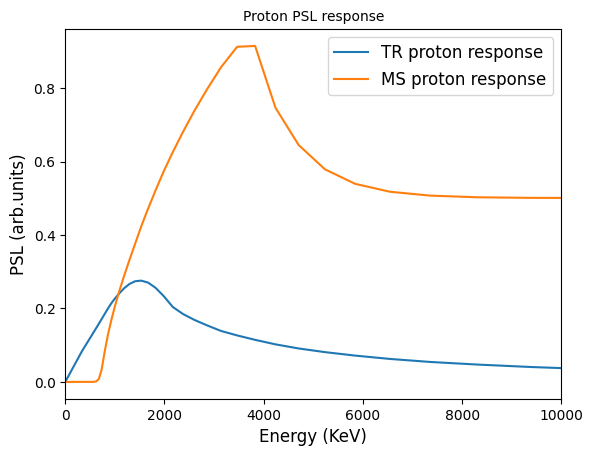

In [88]:
Proton_PSL_data = np.loadtxt('Proton_PSL_linylinx.txt', delimiter=',', skiprows=1)
Proton_PSL_data_low = np.loadtxt('Proton_PSL_low.txt', delimiter=',', skiprows=1)

TR_proton_energy_axis = 1000*Proton_PSL_data[:,0]
TR_proton_PSL_axis = Proton_PSL_data[:,1]

Proton_PSL_data = np.loadtxt('MS_Proton.txt', delimiter=',', skiprows=2)

MS_proton_energy_axis = 1000*Proton_PSL_data[:,0]
MS_proton_PSL_axis = Proton_PSL_data[:,1]

#plt.plot(TR_proton_energy_axis,TR_proton_PSL_axis)

#plt.plot(MS_proton_energy_axis,MS_proton_PSL_axis)

#plt.scatter(TR_proton_energy_axis,TR_proton_PSL_axis)

def find_exp_shift(E, A, a, shift):
    func = (A*np.exp(-a*E))+shift
    return func

def find_poly(E, A, a, shift):
    func = (A*E)**a+shift
    return func

def TR_proton_PSL_scale(Espace):
    PSL = np.interp(Espace,TR_proton_energy_axis,TR_proton_PSL_axis)
    return PSL

coefficients = np.polyfit(np.array([0, 125, 250, 375, 500, 717, 789]), np.array([0, 0, 0, 0, 0, 0.0204, 0.0784]), 8)

x = np.linspace(0,800,50)

poly_fit_MS = np.poly1d(coefficients)

#plt.plot(x,poly_fit_MS(x))

t_2, p_2 = curve_fit(find_exp_shift, np.linspace(4000,5000,100), np.interp(np.linspace(4000,5000,100),MS_proton_energy_axis,MS_proton_PSL_axis), p0=(1,0.0001,0.4))

fit_2 = find_exp_shift(np.linspace(4000,10000,100), t_2[0], t_2[1], t_2[2])

def MS_proton_PSL_scale(Espace):

    t_2, p_2 = curve_fit(find_exp_shift, np.linspace(4000,5000,100), np.interp(np.linspace(4000,5000,100),MS_proton_energy_axis,MS_proton_PSL_axis), p0=(1,0.0001,0.4))

    fit_2 = find_exp_shift(np.linspace(4000,10000,100), t_2[0], t_2[1], t_2[2])

    PSL = np.zeros(len(Espace))
    start = MS_proton_energy_axis[0]
    end = MS_proton_energy_axis[-1]
    
    for i in range(len(Espace)):
        if np.abs(Espace[i]-start) == np.min(np.abs(Espace-start)):
            start_index = i

    for i in range(len(Espace)):
        if np.abs(Espace[i]-end) == np.min(np.abs(Espace-end)):
            end_index = i

    PSL[start_index:end_index] = np.interp(Espace[start_index:end_index],MS_proton_energy_axis,MS_proton_PSL_axis)
    #PSL[:start_index] = MS_proton_PSL_axis[0]
    PSL[:start_index] = poly_fit_MS(Espace[:start_index])
    PSL[end_index:] = np.interp(Espace[end_index:],np.linspace(4000,10000,100),fit_2)

    return PSL

def find_exp(E, A, a):
    func = (A*np.exp(-a*E))
    return func

def find_2exp(E, A, a, B, b):
    func = func = ((A*np.exp(-a*E))+(B*np.exp(-b*E)))
    return func

def find_exp_proton(E, A, a, shift):
    func = (A*np.exp(-a*E))*TR_proton_PSL_scale(E)+shift
    return func

def find_2exp_proton(E, A, a, B, b, shift):
    func = ((A*np.exp(-a*E))+(B*np.exp(-b*E)))*TR_proton_PSL_scale(E)+shift
    return func

def find_temp(E, A, E0, kT):
    func = A*(1/np.sqrt(E))*np.exp((1/kT)*(np.sqrt(E)-np.sqrt(E0))**2)
    return func

##############################################################

energy_data_protons = np.loadtxt('NEPPS_Dispersion_Protons_087T.txt', skiprows=1)
energy_data_electrons = np.loadtxt('NEPPS_Dispersion_Electrons_087T.txt', skiprows=1)

def dxdE_electrons(x_in):
    x_d = np.array(energy_data_electrons[:,1])
    E_d = np.array(energy_data_electrons[:,0])
    dxde_data = np.gradient(x_d,E_d)
    dxde = np.interp(0.1*x_in,x_d,dxde_data)
    return dxde

def dxdE_protons(x_in):
    x_data = np.array(data_protons[1])
    E_data = np.array(data_protons[0])
    dxde_data = np.gradient(x_data,E_data)
    dxde = np.interp(0.1*x_in,x_data,dxde_data)
    return dxde

plt.plot(transform_proton_axis(x_axis,10), TR_proton_PSL_scale(transform_proton_axis(x_axis,10)), label = 'TR proton response')

plt.plot(transform_proton_axis(x_axis,10), MS_proton_PSL_scale(transform_proton_axis(x_axis,10)), label = 'MS proton response')

#plt.plot(np.linspace(4000,10000,100),find_exp_shift(np.linspace(4000,10000,100), t[0], t[1], t[2]))


#plt.plot(x, fit1)

plt.xlim(0,10000)
plt.xlabel("Energy (KeV)")
plt.ylabel("PSL (arb.units)")
plt.title("Proton PSL response")
plt.legend()

Text(0.5, 1.0, 'MS Electron PSL response')

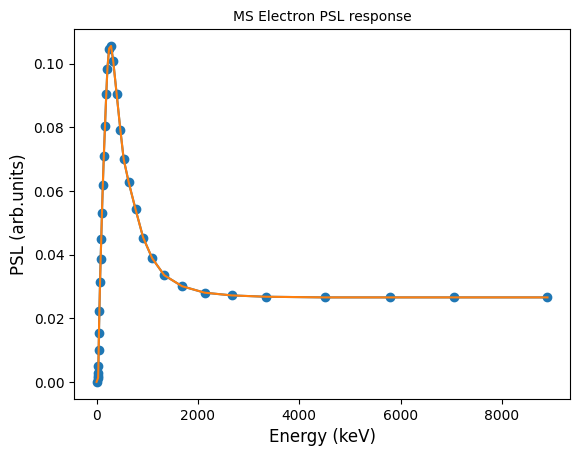

In [89]:
import numpy as np

MS_signal_data = np.loadtxt('MS_signal.txt', skiprows=1) # Adjust delimiter if needed
MS_energy_axis = 1000*MS_signal_data[:,0]
MS_PSL_axis = MS_signal_data[:,1]

plt.plot(MS_energy_axis,MS_PSL_axis)

def MS_PSL_scale(Espace):
    PSL = np.interp(Espace,MS_energy_axis,MS_PSL_axis)
    return PSL

def find_exp_electron(E, A, a, shift):
    func = (A*np.exp(-a*E))*MS_PSL_scale(E)+shift
    return func

def find_2exp_electron(E, A, a, B, b, shift):
    func = ((A*np.exp(-a*E))+(B*np.exp(-b*E)))*MS_PSL_scale(E)+shift
    return func

# Assuming your text file is named 'data.txt' and contains a 2D array
energy_data = np.loadtxt('Electron_Dispersion_Z_vs_Ebeam_0028T.txt', skiprows=8) # Adjust delimiter if needed

MS_signal_data = np.loadtxt('MS_signal.txt', skiprows=1) # Adjust delimiter if needed
MS_energy_axis = 1000*MS_signal_data[:,0]
MS_PSL_axis = MS_signal_data[:,1]

plt.plot(MS_energy_axis,MS_PSL_axis)
plt.scatter(MS_energy_axis,MS_PSL_axis)
plt.xlabel("Energy (keV)")
plt.ylabel("PSL (arb.units)")
plt.title("MS Electron PSL response")
#plt.plot(transform_electron_axis(x_axis,10),MS_PSL_scale(transform_electron_axis(x_axis,10)))
#print(np.shape(energy_data[:,0]))
#print(np.shape(MS_energy_axis))
#plt.xlim([0,100000])
#print(np.shape(data))

In [90]:
def gaussian(x, mu, sigma):
  """
  Calculates the Gaussian function.

  Args:
    x: The input value or array.
    mu: The mean of the Gaussian distribution.
    sigma: The standard deviation of the Gaussian distribution.

  Returns:
    The Gaussian function value(s) at the given input(s).
  """
  term1 = 1 / (sigma * np.sqrt(2 * np.pi))
  term2 = np.exp(-0.5 * ((x - mu) / sigma) ** 2)
  return term1 * term2

Temperature in keV =  1
Bulk speed in c =  0.01
1.7073957598879784e-25


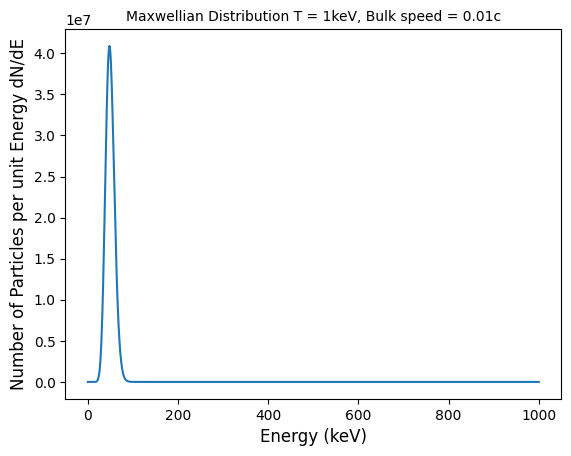

In [91]:
def p_(E, m = 9.11e-31):
    c = 3e8
    E_j = E*(1000*(1.6e-19))
    p = (1/c)*np.sqrt((E_j**2)-((m**2)*(c**4)))
    return p

def gamma(beta):
    gma = 1/(np.sqrt(1-(beta**2)))
    return gma

def Ep_prime(E,beta, particle = 'electron'):
    c = 3e8
    E_j = E*1000*(1.6e-19)
    if particle == 'electron':
        m = 9.11e-31
    elif particle == 'proton':
        m = 1.673e-27
    p = p_(E, m)
    gma = gamma(beta)
    E_prime = gma*(E_j-(beta*c*p))
    p_prime = gma*(p-((beta*E_j)/c))
    return E_prime, p_prime

ratio = 1836.4431104

def rel_maxwell(E, kT, beta, A, particle = 'electron'):
    c = 3e8
    gma = gamma(beta)
    E_j = E*(1000*(1.6e-19))
    if particle == 'electron':
        mass_energy = 512.4376*(1000*(1.6e-19))
    elif particle == 'proton':
        mass_energy = ratio*512.4376*(1000*(1.6e-19))
    else:
        mass_energy = ratio*512.4376*(1000*(1.6e-19))
    if particle == 'electron':
        E_prime, p_prime = Ep_prime(E,beta)
        p = p_(E)
    elif particle == 'proton':
        E_prime, p_prime = Ep_prime(E,beta,particle = 'proton')
        p = p_(E, m = 1.673e-27)
    else:
        E_prime, p_prime = Ep_prime(E,beta,particle = 'proton')
        p = p_(E, m = 1.673e-27)
    #dist = np.exp(-(E_prime/(kT*1000*1.6e-19)))*gma*(1-((beta*p*c)/E_j))*(E_j/(p*c**2))
    ekt = ((E_prime-mass_energy)/(kT*1000*1.6e-19))
    dist = np.exp(-ekt)*gma*(E_j*p/c-((beta*p**2)))
    area = np.trapz(dist,E)
    dist_renormal = A*dist/area
    return dist_renormal

E = np.linspace(0,1000,1000)

#Temp = 900
#Bulk_Speed = 0.05
#Amplitude = 4.5e6

#Temp = 300
#Bulk_Speed = 0.7
#Amplitude = 4.5e6

T = 1
Bulk_Speed = 0.01
Amplitude = 1.0e9

#Temp = 50
#Bulk_Speed = 0.3
#T = ((gamma(Bulk_Speed)*9*9.11e-15)/(1.6e-16))-511
#print(T)
#Amplitude = 1.5e5

#dist = rel_maxwell(E+512.4376,T,Bulk_Speed,Amplitude)
dist = rel_maxwell((E+(ratio*512.4376)),T,Bulk_Speed,Amplitude, particle = 'proton')

plt.plot(E,dist)
#plt.ylim(-100,3000)
#plt.xlim(-100,5000)
plt.xlabel("Energy (keV)")
plt.ylabel("Number of Particles per unit Energy dN/dE")
plt.title('Maxwellian Distribution T = '+str(T)+'keV, Bulk speed = '+str(Bulk_Speed)+'c')

print('Temperature in keV = ', T)
print('Bulk speed in c = ', Bulk_Speed)
print(p_(512.4376))

97.10558814235443
970
[0.00000000e+00 1.00066711e+00 2.00133422e+00 ... 1.49799867e+03
 1.49899933e+03 1.50000000e+03]


/var/folders/mn/__zk_6j559bcx6_fgpwgw61m0000gn/T/ipykernel_13941/1141534429.py:49: RuntimeWarning: invalid value encountered in divide
  dist_renormal = A*dist/area


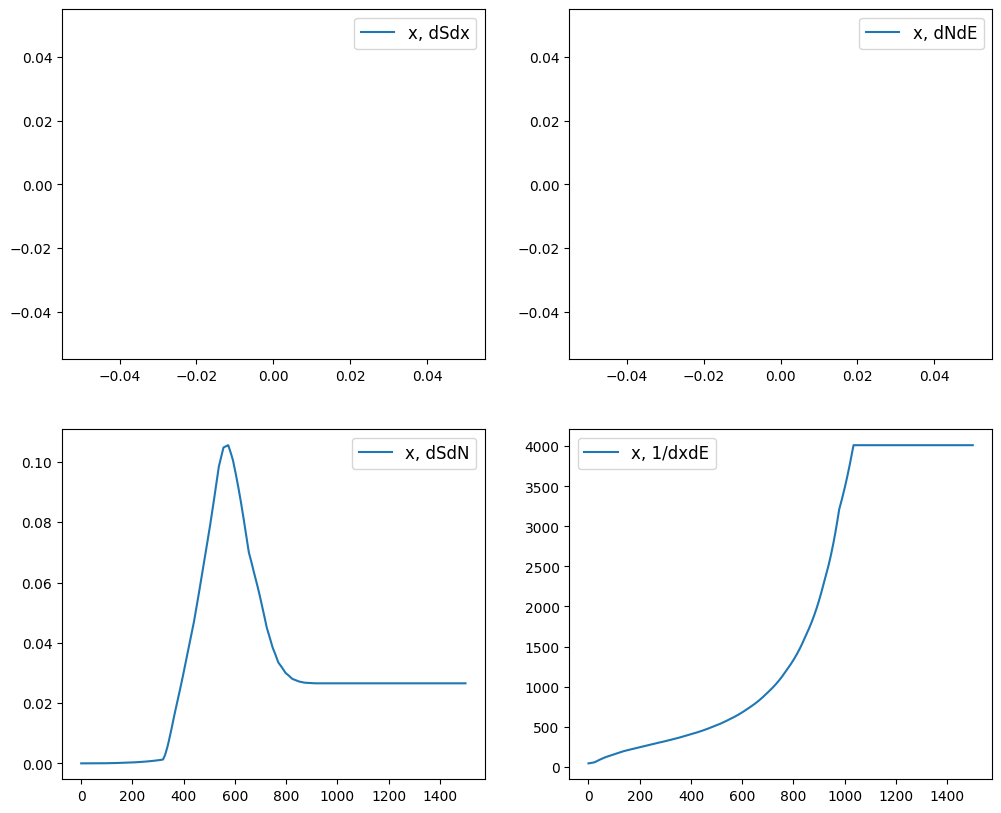

In [92]:
from scipy.ndimage import gaussian_filter
import numpy as np

x_theoretical = np.linspace(0,1500,1500)
E_theoretical = transform_proton_axis(x_theoretical,10)

T = 10
Bulk_Speed = 0.01
Amplitude = 1.0e9

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

dNdE = rel_maxwell(E_theoretical+(ratio*512.4376),T,Bulk_Speed,Amplitude)
dSdN = MS_PSL_scale(E_theoretical)
axs[1,0].plot(x_theoretical,dSdN, label = "x, dSdN")
#axs[1,0].plot(E_theoretical,dSdN)

dSdE = dNdE*dSdN
dSdx = dSdE/dxdE_electrons(x_theoretical)

axs[0,0].plot(x_theoretical,dSdx, label = "x, dSdx")

axs[0,1].plot(x_theoretical,dNdE, label = "x, dNdE")
#axs[0,1].plot(E_theoretical,dNdE)

axs[1,1].plot(x_theoretical,1/(dxdE_electrons(x_theoretical)), label = "x, 1/dxdE")
#axs[1,1].set_ylim(0,10)
#axs[0,0].set_xlim(0,1000)
# Example usage with a 2D array
#filtered_image = gaussian_filter(image, sigma=1)
#print(filtered_image)
axs[0,0].legend()
axs[0,1].legend()
axs[1,0].legend()
axs[1,1].legend()

print(x_theoretical)

103.4301408
1034


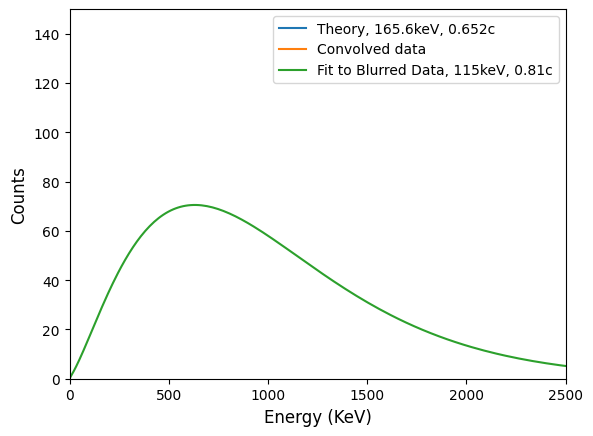

In [93]:
#fig, axs = plt.subplots(1, 2, figsize=(12, 5))

x_theoretical = np.linspace(0,1500,1500)
E_theoretical = transform_electron_axis(x_theoretical,10)

dSdN = MS_PSL_scale(E_theoretical)

chi = 10

slit_function = gaussian(np.linspace(-2*chi,2*chi,4*chi),0,chi)

length = 60
slit_function = (1/length)*(np.ones(length)+np.linspace(-0.01,0.01,length))

dSdx_ = np.convolve(dSdx,slit_function,mode = 'same')

dSdE_ = dSdx_*dxdE_electrons(x_theoretical)

dNdE_ = dSdE_/dSdN

T = 115
Bulk_Speed = 0.81
Amplitude = 9.3e4

dNdE_fit = rel_maxwell(E_theoretical+512.4376,T,Bulk_Speed,Amplitude)
plt.plot(E_theoretical, dNdE, label='Theory, 165.6keV, 0.652c')
plt.plot(E_theoretical, dNdE_, label='Convolved data')
plt.plot(E_theoretical, dNdE_fit, label='Fit to Blurred Data, 115keV, 0.81c')
plt.xlim(0,2500)
plt.ylim(0,150)
plt.xlabel("Energy (KeV)")
plt.ylabel("Counts")
plt.rc('axes', labelsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('legend', fontsize=10)
#plt.title("NEPPS Electron Energy Distribution")
plt.legend()

97.10558814235443
970


/var/folders/mn/__zk_6j559bcx6_fgpwgw61m0000gn/T/ipykernel_13941/924950530.py:51: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,35)
/var/folders/mn/__zk_6j559bcx6_fgpwgw61m0000gn/T/ipykernel_13941/924950530.py:53: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,500)


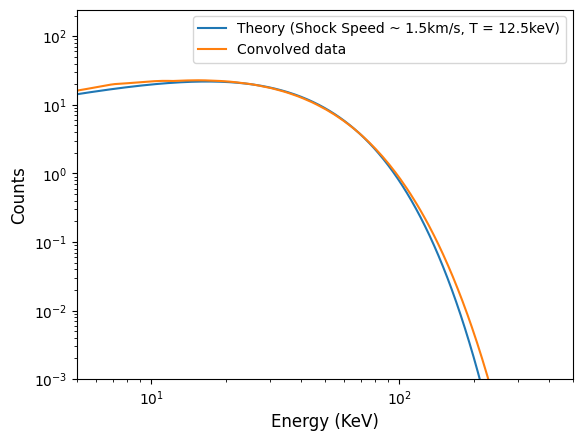

In [94]:
#fig, axs = plt.subplots(1, 2, figsize=(12, 5))

x_theoretical = np.linspace(0,1500,1500)
E_theoretical = transform_proton_axis(x_theoretical,10)

T = 12.5 #temperature from compression, 1.6km/s -> 0.4km/s
Bulk_Speed = 0.005*0.75 #0.005c is 1.5km/s, downstream travels ~1.125km/s
Amplitude = 1e3

#fig, axs = plt.subplots(2, 2, figsize=(12, 10))

dNdE = rel_maxwell(E_theoretical+(ratio*512.4376),T,Bulk_Speed,Amplitude, particle = 'proton')
#dNdE = rel_maxwell(E_theoretical+(ratio*512.4376),5,0.015,Amplitude, particle = 'proton')
dSdN = TR_proton_PSL_scale(E_theoretical)
#axs[1,0].plot(x_theoretical,dSdN, label = "x, dSdN")
#axs[1,0].plot(E_theoretical,dSdN)

dSdE = dNdE*dSdN
dSdx = dSdE/dxdE_protons(x_theoretical)

dSdN = TR_proton_PSL_scale(E_theoretical)

chi = 20

slit_function = gaussian(np.linspace(-2*chi,2*chi,4*chi),0,chi)

length = 60
slit_function = (1/length)*(np.ones(length+1)+np.linspace(-0.1,0.1,length+1))

#slit_function = np.ones(2)

dSdx_ = np.convolve(dSdx,slit_function,mode = 'same')

dSdE_ = dSdx_*dxdE_protons(x_theoretical)

dNdE_ = dSdE_/dSdN


plt.loglog(E_theoretical, dNdE, label='Theory (Shock Speed ~ 1.5km/s, T = 12.5keV)')
plt.loglog(E_theoretical, dNdE_, label='Convolved data')

T = 11
Bulk_Speed = 0.0045*0.75
Amplitude = 1e3

#dNdE_fit = rel_maxwell(E_theoretical+(ratio*512.4376),T,Bulk_Speed,Amplitude, particle='protons')
#plt.plot(E_theoretical, dNdE_fit, label='Fit to Blurred Data, 115keV, 0.76c')
#low energy
plt.xlim(5,800)
#plt.xlim(5,150)
plt.ylim(0,35)

plt.xlim(0,500)
plt.ylim(1e-3,35*7)

#high energy
#plt.xlim(2000,8000)
#plt.ylim(0,0.2)
#plt.xlim(5,1000)
#plt.ylim(1e-3,100)

plt.xlabel("Energy (KeV)")
plt.ylabel("Counts")
plt.rc('axes', labelsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('legend', fontsize=10)
#plt.title("NEPPS Electron Energy Distribution")
plt.legend()

In [36]:
##code for initializing MagSpec##
import MagSpec
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.interpolate as spint

#Field from Gennady
NEPPS_Field = (88.6/79)*np.loadtxt('Magnetic_Field_NEPPS.txt', skiprows=1)

Baxes, Bdata = NEPPS_Field[:,0], NEPPS_Field[:,1]

Spec = MagSpec.MagSpec()

Spec.mag_field(Baxes,Bdata)

Spec.fineadjustment(fine_adjustment = 16)

##end of initialization for MagSpec##

Spectrometer Initialized!


0.045563105543437246


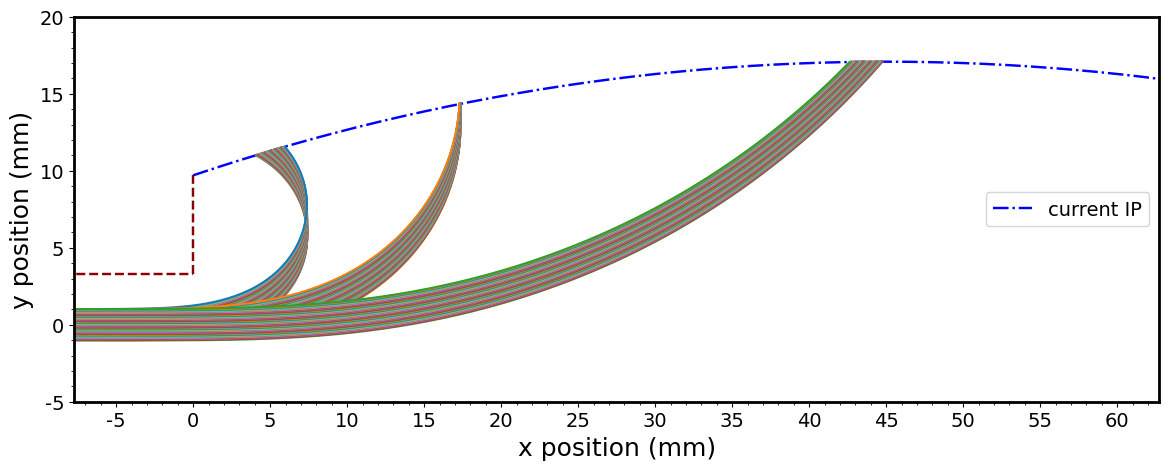

In [37]:
##code for plotting particle trajectories##
import matplotlib.ticker as ticker

#fig, ax = plt.subplots()
fig, ax = Spec.plotIP(figsize = [14,5])

#various energies to test
#Energy = 10000
#Energy = 5260
#Energy = 5000
#Energy = 5500
#Energy = 2000
#Energy = 150

Energies = [500,5260,1e5]

for Energy in Energies:

    IP_dist_val, X_data, Y_data, Z_data = Spec.track_1D_slit(
        plotting = True,
        Energy_eV = Energy,
        source = 'point',
        Range = np.linspace(-0.002,0.002,51), 
        #Range = np.linspace(-0.0005,0.0005,21), 
        theta_z = 0,
        theta_0 = 0)

##start of code for plotting particle trajectories##

#zoom in!
xc = 0.015
yc = 0.014
w = 0.005
#plt.xlim(xc-w,xc+w)
#plt.ylim(yc-w,yc+w)
#print(Spec.TCC_x)

#better view of tracks
plt.xlim(-0.005,0.06)
plt.ylim(-0.005,0.02)
plt.xlabel('x position (m)')
plt.ylabel('y position (m)')
# SMALL_SIZE = 10
# MEDIUM_SIZE = 12
# BIGGER_SIZE = 10
# plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
# plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
# plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
# plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
# plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
# plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize

ax.set_xlabel('x position (mm)',fontsize = 18)
ax.set_ylabel('y position (mm)',fontsize = 18)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.005))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.001))
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.005))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.001))
ax.tick_params(labelsize = 14)

xticklabels = np.array([-5,0,5,10,15,20,25,30,35,40,45,50,55,60])
yticklabels = np.array([-5,0,5,10,15,20])

xticks = 0.001*xticklabels
yticks = 0.001*yticklabels

plt.xticks(ticks=xticks, labels=xticklabels)
plt.yticks(ticks=yticks, labels=yticklabels)


# plt.xticks(labels=[-5,0,5,10,15,20,25,30,35,40,45,50,55,60])
# plt.yticks(labels=[-5,0,5,10,15,20])

#ax.ticklabel_format(style = 'scientific', scilimits=(1,4))

plt.legend(loc = 5, fontsize = 14)

print(IP_dist_val[0])

##end of code for plotting particle trajectories##

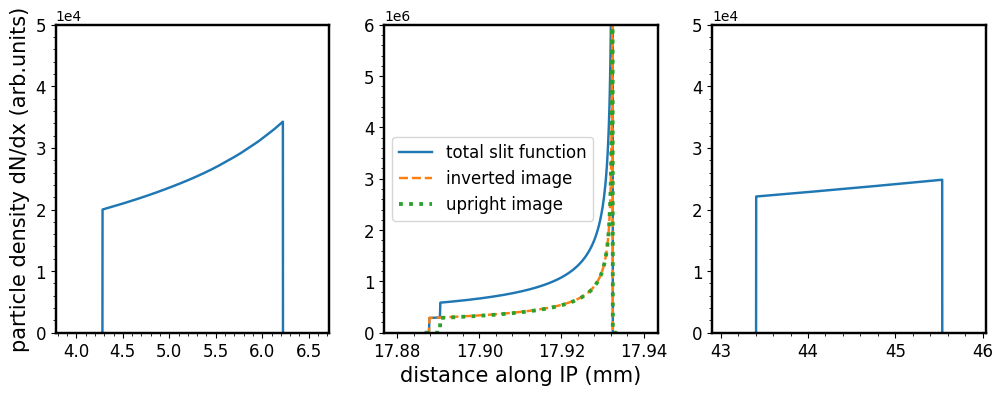

In [38]:
##code for plotting slit functions##
import matplotlib.ticker as ticker

fig, ax = plt.subplots(1,3,figsize = [12,4])

N_energies = 3
Energies = [500,5260,100000]
Spec.delta_d = 0.0001

for i in range(0,3):
    Energy = Energies[i]

    IP_dist_val, X_data, Y_data, Z_data = Spec.track_1D_slit(
        plotting = False,
        Energy_eV = Energy,
        source = 'point',
        Range = np.linspace(-0.002,0.002,51), 
        theta_z = 0,
        theta_0 = 0)

    IP_linspace, Particle_Density, Particle_Density_a, Particle_Density_b = Spec.slit_function_precise(IP_dist_val)
    ax[i].plot(IP_linspace*1000, Particle_Density, label = 'total slit function', linewidth = 1.75)

    if i == 1:
        ax[i].set_ylim(0,0.6e7)
        ax[i].set_xlim(1000*IP_linspace[0]-0.01,1000*IP_linspace[-1]+0.01)
        ax[i].plot(IP_linspace*1000, Particle_Density_a, linestyle = '--', label = 'inverted image', linewidth = 1.75)
        ax[i].plot(IP_linspace*1000, Particle_Density_b, linestyle = ':', label = 'upright image', linewidth = 2.75)
        ax[i].legend(loc = 6, fontsize = 12)
    else:
        ax[i].set_ylim(0,5e4)
        ax[i].set_xlim(1000*IP_linspace[0]-0.5,1000*IP_linspace[-1]+0.5)
        #ax[i].legend(fontsize = 8)

    if i == 0:
        ax[i].set_ylabel('particle density dN/dx (arb.units)',fontsize = 15)
    elif i == 1:
        ax[i].set_xlabel('distance along IP (mm)',fontsize = 15)
    for location in ['left', 'right', 'top', 'bottom']:
        ax[i].spines[location].set_linewidth(1.75)


ax[0].yaxis.set_major_locator(ticker.MultipleLocator(10e3))
ax[0].yaxis.set_minor_locator(ticker.MultipleLocator(20e2))
ax[0].xaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax[0].xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax[0].tick_params(labelsize = 12)
ax[0].ticklabel_format(style = 'scientific', scilimits=(1,4))

ax[1].yaxis.set_major_locator(ticker.MultipleLocator(1e6))
ax[1].yaxis.set_minor_locator(ticker.MultipleLocator(2e5))
ax[1].xaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax[1].xaxis.set_minor_locator(ticker.MultipleLocator(0.004))
ax[1].tick_params(labelsize = 12)
ax[1].ticklabel_format(style = 'sci')

ax[2].yaxis.set_major_locator(ticker.MultipleLocator(10e3))
ax[2].yaxis.set_minor_locator(ticker.MultipleLocator(20e2))
ax[2].xaxis.set_major_locator(ticker.MultipleLocator(1))
ax[2].xaxis.set_minor_locator(ticker.MultipleLocator(0.2))
ax[2].tick_params(labelsize = 12)
ax[2].ticklabel_format(style = 'scientific', scilimits=(0,4))

#fig.tight_layout()

#>>end of code for plotting slit function


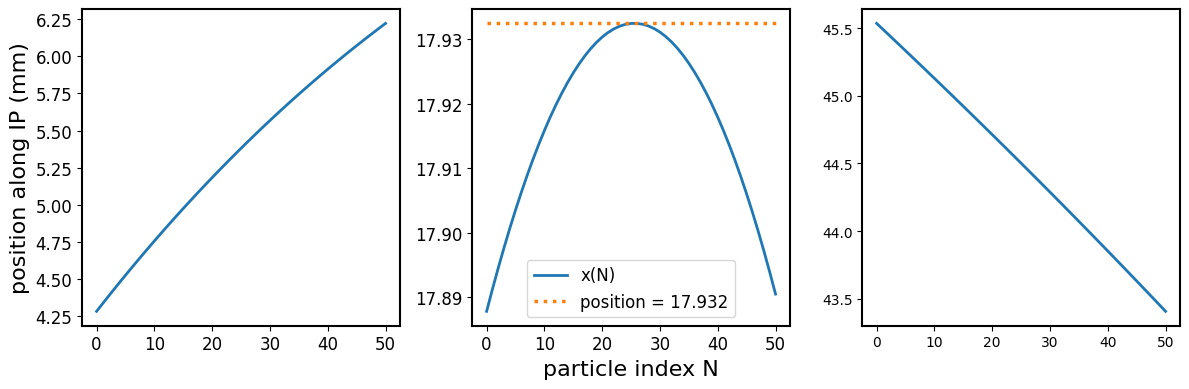

In [55]:
##code for plotting x(N)##
fig, ax = plt.subplots(1,3,figsize = [12,4])

N_energies = 3
Energies = [500,5260,100000]
Spec.delta_d = 0.0001

for i in range(0,3):
    Energy = Energies[i]

    IP_dist_val, X_data, Y_data, Z_data = Spec.track_1D_slit(
        plotting = False,
        Energy_eV = Energy,
        source = 'point',
        Range = np.linspace(-0.002,0.002,51), 
        theta_z = 0,
        theta_0 = 0)
    
    indexes = np.linspace(0,len(IP_dist_val)-1,len(IP_dist_val))
    ax[i].plot(indexes, 1000*IP_dist_val, linewidth = 2, label = 'x(N)')
    if i == 0:
        ax[i].set_ylabel('position along IP (mm)', fontsize = 16)
        ax[i].tick_params(labelsize = 12)
    elif i == 1:
        ax[i].set_xlabel('particle index N', fontsize = 16)
        ax[i].tick_params(labelsize = 12)
        ax[i].plot(np.linspace(0,50,10),17.9324*np.ones(10), linewidth = 2.5, linestyle = ':', label = 'position = 17.932')
        ax[i].legend(fontsize = 12)


    for location in ['left', 'right', 'top', 'bottom']:
        ax[i].spines[location].set_linewidth(1.5)


fig.tight_layout()

#>>end of code for plotting slit function


/var/folders/mn/__zk_6j559bcx6_fgpwgw61m0000gn/T/ipykernel_13941/3187123542.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


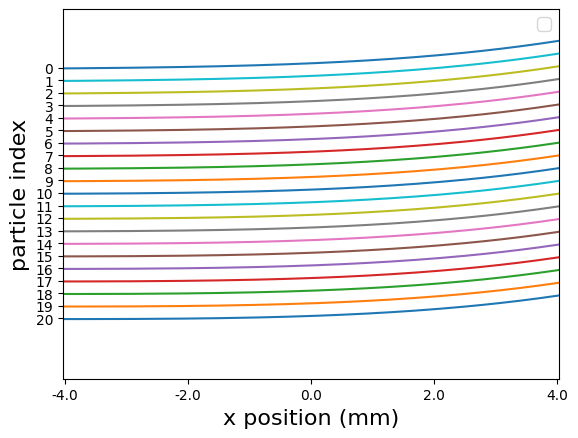

In [59]:
##code for plotting x(N) part 2##
import math

#fig, ax = plt.subplots()
#Spec.plotIP(figsize = [6,6])

slitrange = np.linspace(-0.004,0.004,21)
Energies = [5260]

for Energy in Energies:

    IP_dist_val, X_data, Y_data, Z_data = Spec.track_1D_slit(
        plotting = True,
        Energy_eV = Energy,
        source = 'point',
        Range = slitrange, 
        theta_z = 0,
        theta_0 = 0)

##start of code for plotting particle trajectories##

#better view of tracks
plt.xlim(-0.003,0.003)
plt.ylim(-0.003,0.003)

yticks = []
for theta in slitrange:
    yticks.append(0.509*math.sin(theta)+0.000015)
yticks = np.array(yticks)
ticklabels_array = np.linspace(0,len(yticks)-1,len(yticks))
ticklabels = []
for index in range(len(ticklabels_array)):
    ticklabels.append(int(ticklabels_array[-1-index]))
plt.yticks(ticks=yticks, labels=ticklabels)

xticks = np.array([-0.004,-0.002,0,0.002,0.004])
xtickslabels = 1000*xticks

plt.xticks(ticks=xticks, labels=xtickslabels)

plt.xlabel('x position (mm)', fontsize = 16)
plt.ylabel('particle index', fontsize = 16)
SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 10
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize

plt.legend()

##end of code for plotting particle trajectories##

In [26]:
###Cell for finding deltaE/E###

#>>initializing MagSpec
import matplotlib.ticker as ticker
import MagSpec
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.interpolate as spint

B_list = [30,60,88.6]
energy_list_a = np.logspace(np.log10(500),np.log10(1000500),1000)
energy_list_b = np.linspace(500,1000500,1000)

Frac_Uncertainty_log_bfield = []
Frac_Uncertainty_lin_bfield = []

Frac_Uncertainty_log_slit = []
Frac_Uncertainty_lin_slit = []

slit_widths = [0.001, 0.002, 0.004, 0.006]

for i in range(0,3):

    NEPPS_Field = (B_list[i]/79)*np.loadtxt('Magnetic_Field_NEPPS.txt', skiprows=1)

    Baxes, Bdata = NEPPS_Field[:,0], NEPPS_Field[:,1]

    Spec = MagSpec.MagSpec()

    Spec.mag_field(Baxes,Bdata)

    Spec.fineadjustment(fine_adjustment = 8)

    Spec.TCC(-0.2,0,0)

    delta_e_over_E_list_a = Spec.delta_E_spread(
        E_space = energy_list_a,
        source = 'point',
        Range = np.linspace(-0.005,0.005,51),
        theta_0 = 0,
        theta_z = 0,
        Padding=[0.75,1],
        type="x-centered")
    
    Frac_Uncertainty_log_bfield.append(delta_e_over_E_list_a)

    delta_e_over_E_list_b = Spec.delta_E_spread(
        E_space = energy_list_b,
        source = 'point',
        Range = np.linspace(-0.005,0.005,51),
        theta_0 = 0,
        theta_z = 0,
        Padding=[0.75,1],
        type="x-centered")
    
    Frac_Uncertainty_lin_bfield.append(delta_e_over_E_list_b)

##code for calculating uncertainty of various slits##

for i in range(0,4):

    #Field from Gennady
    NEPPS_Field = (88.6/79)*np.loadtxt('Magnetic_Field_NEPPS.txt', skiprows=1)

    Baxes, Bdata = NEPPS_Field[:,0], NEPPS_Field[:,1]

    Spec = MagSpec.MagSpec()

    Spec.mag_field(Baxes,Bdata)

    Spec.fineadjustment(fine_adjustment = 8)

    Spec.TCC(-0.2,0,0)

    slit_width = slit_widths[i]
    input_range = np.linspace(-slit_width/(2*0.2),slit_width/(2*0.2),51)

    delta_e_over_E_list_a = Spec.delta_E_spread(
        E_space = energy_list_a,
        source = 'point',
        Range = input_range,
        theta_0 = 0,
        theta_z = 0,
        Padding=[0.75,1],
        type="x-centered")
    
    Frac_Uncertainty_log_slit.append(delta_e_over_E_list_a)

    delta_e_over_E_list_b = Spec.delta_E_spread(
        E_space = energy_list_b,
        source = 'point',
        Range = input_range,
        theta_0 = 0,
        theta_z = 0,
        Padding=[0.75,1],
        type="x-centered")
    
    Frac_Uncertainty_lin_slit.append(delta_e_over_E_list_b)

np.save('Frac_Uncertainty_lin_slit', Frac_Uncertainty_lin_slit)
np.save('Frac_Uncertainty_log_slit', Frac_Uncertainty_log_slit)

np.save('Frac_Uncertainty_lin_bfield', Frac_Uncertainty_lin_bfield)
np.save('Frac_Uncertainty_log_bfield', Frac_Uncertainty_log_bfield)


Spectrometer Initialized!
Spectrometer Initialized!
Spectrometer Initialized!
Spectrometer Initialized!
Spectrometer Initialized!
Spectrometer Initialized!
Spectrometer Initialized!


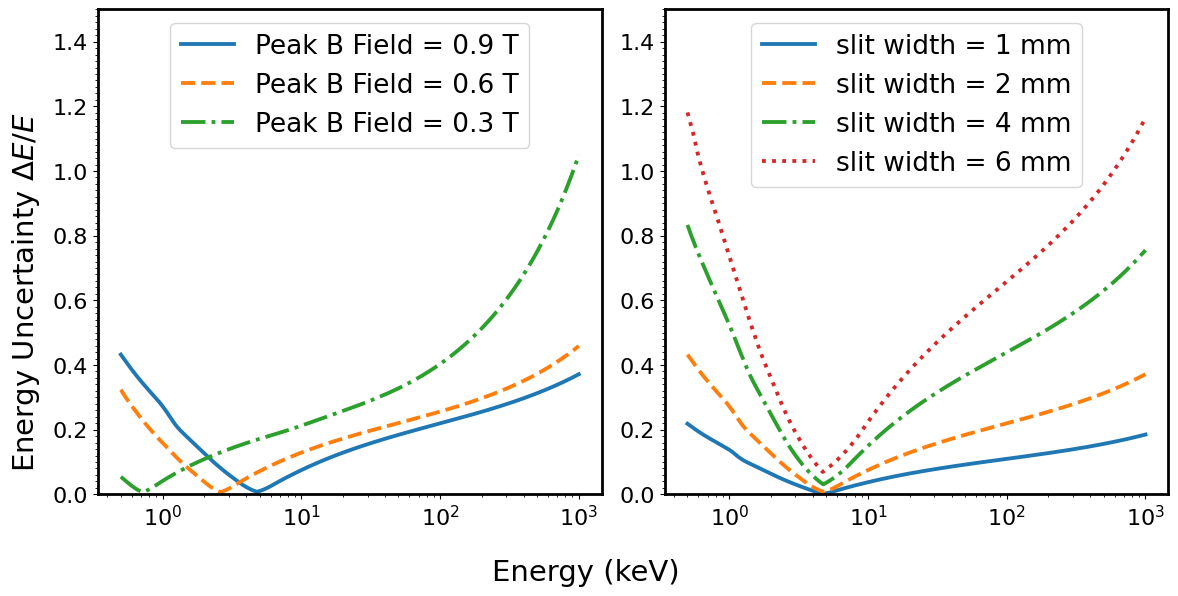

In [28]:
##Cell for plotting DeltaE/E##

Frac_Uncertainty_log_bfield = np.load('Frac_Uncertainty_log_bfield.npy')
Frac_Uncertainty_log_slit = np.load('Frac_Uncertainty_log_slit.npy')

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

for i in range(len(B_list)):
    
    B_magnitude = B_list[-1-i]

    if i == 0:
        L = '-'
    elif i == 1:
        L = "--"
    elif i == 2:
        L = "-."
    else:
        L = ":"


    axs[0].semilogx(energy_list_a/1e3, Frac_Uncertainty_log_bfield[-1-i], linestyle = L, label = ("Peak B Field = " + str(round(B_magnitude/10)/10) + " T"), linewidth = 2.75)

for i in range(len(slit_widths)):
    
    Slit_Width = 1000*slit_widths[i]

    if i == 0:
        L = '-'
    elif i == 1:
        L = "--"
    elif i == 2:
        L = "-."
    else:
        L = ":"

    axs[1].semilogx(energy_list_a/1e3, Frac_Uncertainty_log_slit[i], linestyle = L, label = ("slit width = " + str(round(Slit_Width)) + " mm"), linewidth = 2.75)


axs[0].legend(fontsize = '19', loc = 9)
axs[1].legend(fontsize = '19', loc = 9)

fig.supxlabel('Energy (keV)', fontsize = '21')
fig.supylabel('Energy Uncertainty $\Delta E/E$', fontsize = '21')

axs[0].yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axs[0].yaxis.set_minor_locator(ticker.MultipleLocator(0.02))
axs[0].set_ylim(0,1.5)
axs[0].tick_params(labelsize = 16)

#axs[1].xaxis.set_major_locator(ticker.MultipleLocator(100000))
#axs[1].xaxis.set_minor_locator(ticker.MultipleLocator(20000))
axs[1].yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axs[1].yaxis.set_minor_locator(ticker.MultipleLocator(0.02))
axs[1].set_ylim(0,1.5)
axs[1].tick_params(labelsize = 16)

for location in ['left', 'right', 'top', 'bottom']:
    axs[0].spines[location].set_linewidth(2)
    axs[1].spines[location].set_linewidth(2)

fig.tight_layout(pad = 1.25, h_pad = 0)

In [8]:
##Cell for finding various slit functions##

#>>initializing MagSpec
import matplotlib.ticker as ticker
import MagSpec
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.interpolate as spint

NEPPS_Field = (88.6/79)*np.loadtxt('Magnetic_Field_NEPPS.txt', skiprows=1)
Baxes, Bdata = NEPPS_Field[:,0], NEPPS_Field[:,1]
Spec = MagSpec.MagSpec()
Spec.mag_field(Baxes,Bdata)
Spec.fineadjustment(fine_adjustment = 8)

x_space, plot_data_axes, slit_function_data, IP_data = Spec.varying_slit_function(
        resolution = 0.0001,
        E_space = np.linspace(1000,500000,500),
        source = 'point',
        Range = np.linspace(-0.002,0.002,51),
        theta_0 = 0,
        theta_z = 0,
        precise = True)

Spectrometer Initialized!


559


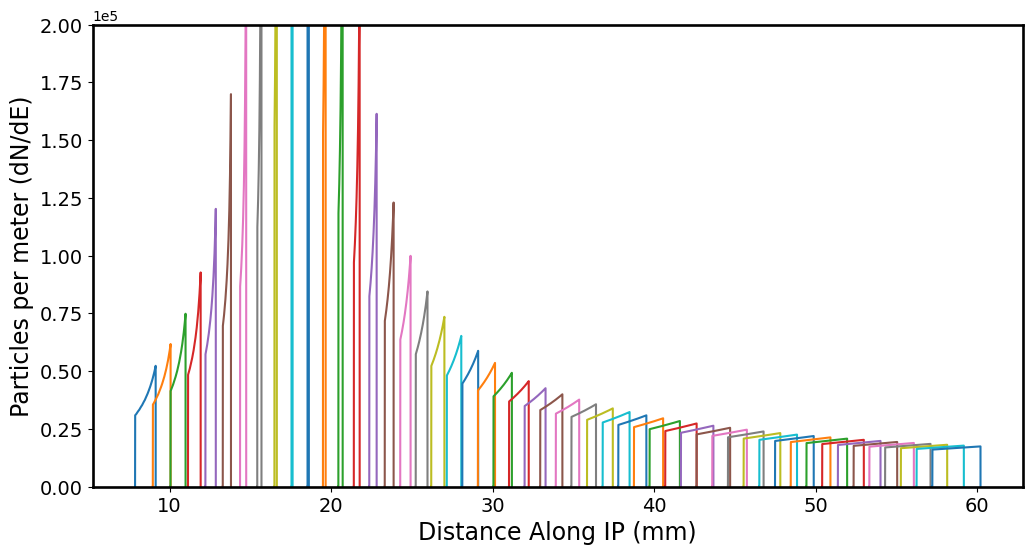

In [22]:
##Cell for plotting various slit functions##

fig, axs = plt.subplots(figsize=(12, 6))

print(len(x_space))
for i in np.linspace(0,500,51).astype(int):
    axs.plot(plot_data_axes[i]*1000,slit_function_data[i])

#plt.ylim(2e7,4.7e7)
axs.set_ylim(0,2e5)
c = 0.0181
w = 0.0001
#plt.title("Slit Function at Various Positions along IP")
axs.set_xlabel("Distance Along IP (mm)", fontsize = 17)
axs.set_ylabel("Particles per meter (dN/dE)", fontsize = 17)
axs.ticklabel_format(style = 'scientific', scilimits=(0,5))
axs.tick_params(labelsize = 14)
for location in ['left', 'right', 'top', 'bottom']:
    axs.spines[location].set_linewidth(1.9)
#plt.xlim(c-w,c+w)

In [ ]:
##Cell for finding optimal IP configuration##



Spectrometer Initialized!


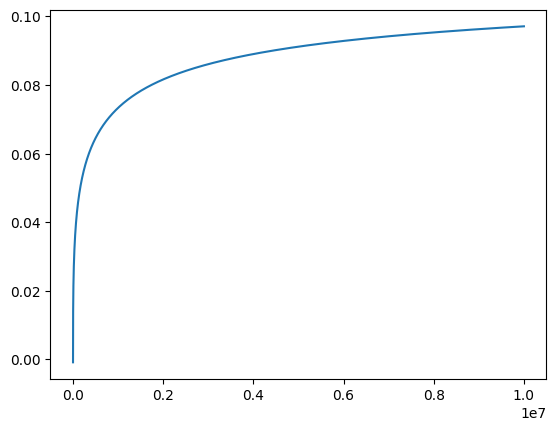

In [ ]:
##Cell for finding very accurate dispersion relation##

#>>initializing MagSpec
import matplotlib.ticker as ticker
import MagSpec
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.interpolate as spint

NEPPS_Field = (88.6/79)*np.loadtxt('Magnetic_Field_NEPPS.txt', skiprows=1)
Baxes, Bdata = NEPPS_Field[:,0], NEPPS_Field[:,1]
Spec = MagSpec.MagSpec()
Spec.mag_field(Baxes,Bdata)
Spec.fineadjustment(fine_adjustment = 8)
Spec.TCC(-0.2,0,0)
Spec.delta_d = 0.0001

##finding EXDispersion##
#Espace_big = np.concatenate((np.linspace(125,4025,156),np.linspace(4050,5000,33),np.linspace(5037.5,5075,2),np.linspace(5125,10125,101),np.array([10125+3333,10125+6667]),np.linspace(11125, 10000125, 10001-11)))
Espace_big = np.concatenate(((np.linspace(100**(1/3),10125**(1/3),35))**3,np.linspace(11125, 10000125, 10001-11)))
Xspace_big = Spec.EXdispersion(Espace_big, y_0 = 0, theta_0 = 0, track_termination=True)
np.save('Espace_big', Espace_big)
np.save('Xspace_big', Xspace_big)
plt.plot(Espace_big,Xspace_big)


In [24]:
#>>initializing MagSpec
import matplotlib.ticker as ticker
import MagSpec
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.interpolate as spint

NEPPS_Field = (88.6/79)*np.loadtxt('Magnetic_Field_NEPPS.txt', skiprows=1)
Baxes, Bdata = NEPPS_Field[:,0], NEPPS_Field[:,1]
Spec = MagSpec.MagSpec()
Spec.fineadjustment(fine_adjustment = 8)
Spec.TCC(-0.2,0,0)
Spec.delta_d = 0.0001
Espace_med = np.concatenate(((np.linspace(100**(1/3),10125**(1/3),17))**3,np.linspace(11125, 10000125, 5001-6)))

NEPPS_Field = (88.6/79)*np.loadtxt('Magnetic_Field_NEPPS.txt', skiprows=1)
Baxes, Bdata = NEPPS_Field[:,0], NEPPS_Field[:,1]
Spec = MagSpec.MagSpec()
Spec.mag_field(Baxes,Bdata)

Xspace_9000G = Spec.EXdispersion(Espace_med, y_0 = 0, theta_0 = 0, track_termination=True)
print('dispersion done.')

NEPPS_Field = (60/79)*np.loadtxt('Magnetic_Field_NEPPS.txt', skiprows=1)
Baxes, Bdata = NEPPS_Field[:,0], NEPPS_Field[:,1]
Spec = MagSpec.MagSpec()
Spec.mag_field(Baxes,Bdata)

Xspace_6000G = Spec.EXdispersion(Espace_med, y_0 = 0, theta_0 = 0, track_termination=True)
print('dispersion done.')

NEPPS_Field = (30/79)*np.loadtxt('Magnetic_Field_NEPPS.txt', skiprows=1)
Baxes, Bdata = NEPPS_Field[:,0], NEPPS_Field[:,1]
Spec = MagSpec.MagSpec()
Spec.mag_field(Baxes,Bdata)

Xspace_3000G = Spec.EXdispersion(Espace_med, y_0 = 0, theta_0 = 0, track_termination=True)
print('dispersion done.')


Spectrometer Initialized!
Spectrometer Initialized!
dispersion done.
Spectrometer Initialized!
dispersion done.
Spectrometer Initialized!
dispersion done.


[   10.            12.91549665    16.68100537    21.5443469
    27.82559402    35.93813664    46.41588834    59.94842503
    77.42636827   100.           129.1549665    166.8100537
   215.443469     278.2559402    359.3813664    464.1588834
   599.4842503    774.2636827   1000.          1291.549665
  1668.100537    2154.43469     2782.559402    3593.813664
  4641.588834    5994.842503    7742.636827   10000.        ]
[22.40717395 24.40017165 26.50650379 28.73267235 31.07976596 33.54840525
 36.14376645 38.85352596 41.67337472 44.60501882 47.6335025  50.74641978
 53.93001712 57.16849505 60.44479424 63.72882309 67.00267604 70.24534086
 73.43372005 76.54447402 79.56220252 82.47234791 85.25594612 87.90024317
 90.39749862 92.74273568 94.9328624  96.96670344]


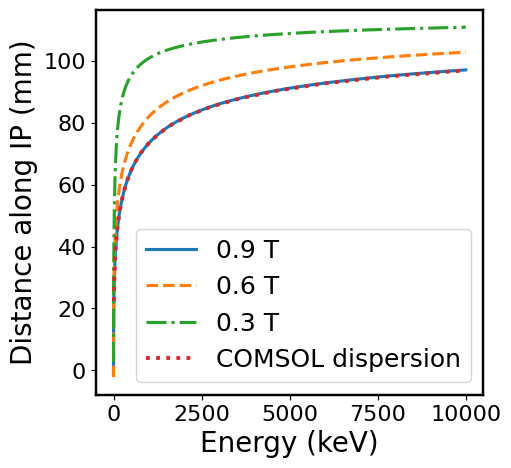

In [25]:
fig, ax = plt.subplots(figsize = [5,5])

Espace_big = np.load('Espace_big.npy')
Xspace_big = np.load('Xspace_big.npy')

ax.plot(Espace_med*1e-3,Xspace_9000G*1e3,linewidth=2.25, label = '0.9 T')
ax.plot(Espace_med*1e-3,Xspace_6000G*1e3,linestyle='--',linewidth=2.25, label = '0.6 T')
ax.plot(Espace_med*1e-3,Xspace_3000G*1e3,linestyle='-.',linewidth=2.25, label = '0.3 T')

COMSOL_dispersion = np.loadtxt('NEPPS_Dispersion_Protons_087T.txt', skiprows = 1)
print(COMSOL_dispersion[:,0])
print(COMSOL_dispersion[:,1])
ax.plot(COMSOL_dispersion[:,0],COMSOL_dispersion[:,1], linestyle = ':', linewidth=2.75, label = 'COMSOL dispersion')

ax.set_xlabel('Energy (keV)',fontsize = 20)
ax.set_ylabel('Distance along IP (mm)',fontsize = 20)
ax.tick_params(labelsize = 16)
ax.legend(fontsize = 18)

for location in ['left', 'right', 'top', 'bottom']:
    ax.spines[location].set_linewidth(1.75)

[   10.            12.91549665    16.68100537    21.5443469
    27.82559402    35.93813664    46.41588834    59.94842503
    77.42636827   100.           129.1549665    166.8100537
   215.443469     278.2559402    359.3813664    464.1588834
   599.4842503    774.2636827   1000.          1291.549665
  1668.100537    2154.43469     2782.559402    3593.813664
  4641.588834    5994.842503    7742.636827   10000.        ]
[22.40717395 24.40017165 26.50650379 28.73267235 31.07976596 33.54840525
 36.14376645 38.85352596 41.67337472 44.60501882 47.6335025  50.74641978
 53.93001712 57.16849505 60.44479424 63.72882309 67.00267604 70.24534086
 73.43372005 76.54447402 79.56220252 82.47234791 85.25594612 87.90024317
 90.39749862 92.74273568 94.9328624  96.96670344]


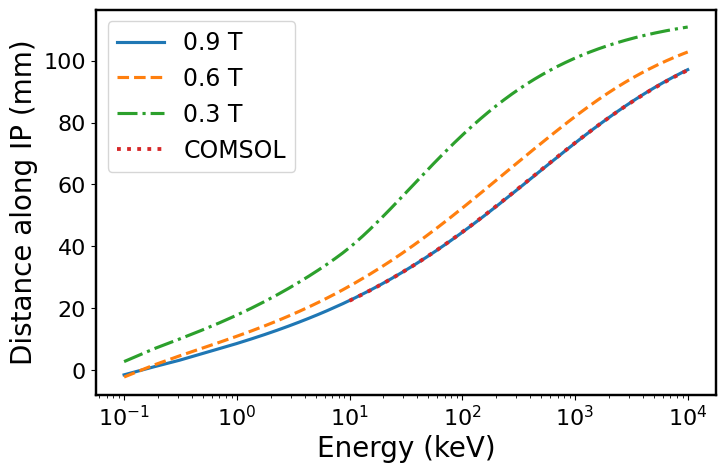

In [101]:
fig, ax = plt.subplots(figsize = [8,5])

Espace_big = np.load('Espace_big.npy')
Xspace_big = np.load('Xspace_big.npy')

ax.semilogx(Espace_med*1e-3,Xspace_9000G*1e3,linewidth=2.25, label = '0.9 T')
ax.semilogx(Espace_med*1e-3,Xspace_6000G*1e3,linestyle='--',linewidth=2.25, label = '0.6 T')
ax.semilogx(Espace_med*1e-3,Xspace_3000G*1e3,linestyle='-.',linewidth=2.25, label = '0.3 T')

COMSOL_dispersion = np.loadtxt('NEPPS_Dispersion_Protons_087T.txt', skiprows = 1)
print(COMSOL_dispersion[:,0])
print(COMSOL_dispersion[:,1])
ax.semilogx(COMSOL_dispersion[:,0],COMSOL_dispersion[:,1], linestyle = ':', linewidth=2.75, label = 'COMSOL')

ax.set_xlabel('Energy (keV)',fontsize = 20)
ax.set_ylabel('Distance along IP (mm)',fontsize = 20)
ax.tick_params(labelsize = 16)
ax.legend(fontsize = 17)

for location in ['left', 'right', 'top', 'bottom']:
    ax.spines[location].set_linewidth(1.75)

Spectrometer Initialized!


Text(0, 0.5, 'particles per unit distance')

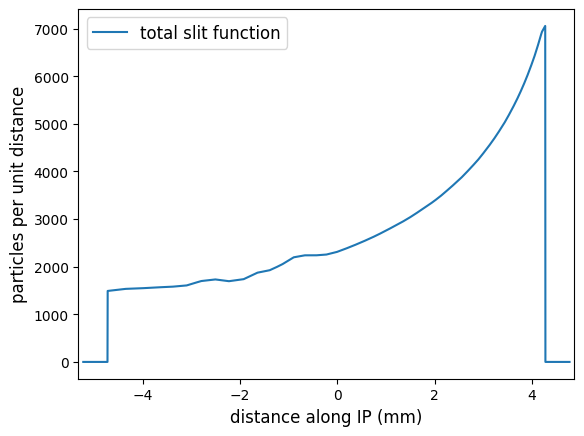

In [71]:
##plotting a single accurate slit function##

#>>initializing MagSpec
import matplotlib.ticker as ticker
import MagSpec
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.interpolate as spint

NEPPS_Field = (88.6/79)*np.loadtxt('Magnetic_Field_NEPPS.txt', skiprows=1)
Baxes, Bdata = NEPPS_Field[:,0], NEPPS_Field[:,1]
Spec = MagSpec.MagSpec()
Spec.mag_field(Baxes,Bdata)
Spec.fineadjustment(fine_adjustment = 8)
Spec.TCC(-0.2,0,0)
Spec.delta_d = 0.0002
Energy = 200

IP_dist_val, X_data, Y_data, Z_data = Spec.track_1D_slit(
    plotting = False,
    Energy_eV = Energy,
    source = 'point',
    Range = np.linspace(-0.0125,0.0125,51), 
    theta_z = 0,
    theta_0 = 0)

IP_linspace, Particle_Density, Particle_Density_a, Particle_Density_b = Spec.slit_function(IP_dist_val)
plt.plot(IP_linspace*1000, Particle_Density, label = 'total slit function')
#plt.plot(IP_linspace*1000, Particle_Density_a, linestyle = ':', label = 'inverted image')
#plt.plot(IP_linspace*1000, Particle_Density_b, linestyle = '-.', label = 'non-inverted image')
plt.xlim(1000*IP_linspace[0]-0.1,1000*IP_linspace[-1]+0.1)
plt.rc('font',size=8)
plt.legend()
plt.xlabel('distance along IP (mm)')
plt.ylabel('particles per unit distance')

In [80]:
arr = np.array([0,1,2,3,4,5,20,4,2,1,0])
condition = np.argmax(arr)
print(condition)

6


Spectrometer Initialized!
0.0


(1, 1000000000000.0)

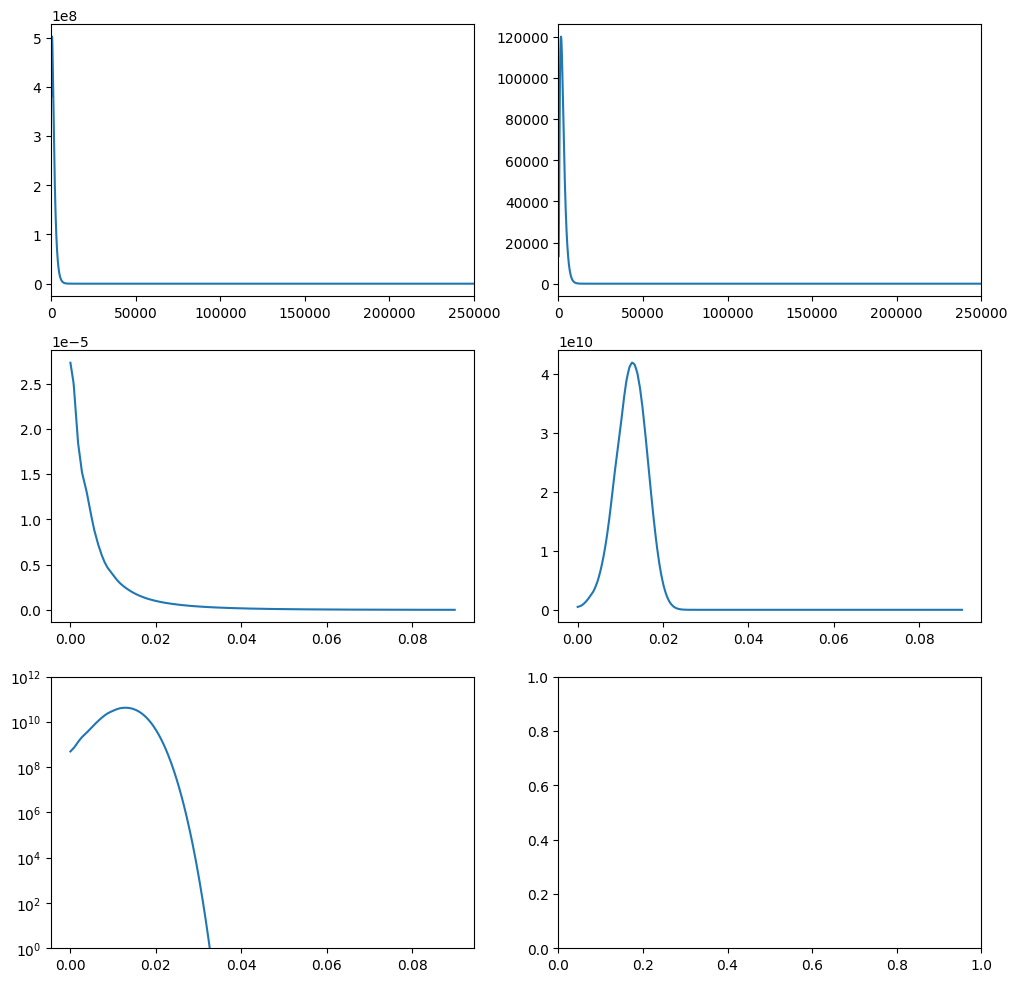

In [ ]:
##finding slit functions for each position in an array##

#>>initializing MagSpec
import matplotlib.ticker as ticker
import MagSpec
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.interpolate as spint

NEPPS_Field = (88.6/79)*np.loadtxt('Magnetic_Field_NEPPS.txt', skiprows=1)
Baxes, Bdata = NEPPS_Field[:,0], NEPPS_Field[:,1]
Spec = MagSpec.MagSpec()
Spec.mag_field(Baxes,Bdata)
Spec.fineadjustment(fine_adjustment = 8)
Spec.TCC(-0.2,0,0)
Spec.delta_d = 0.0002

def Efromx(x):
    Espace_big = np.load('Espace_big.npy')
    Xspace_big = np.load('Xspace_big.npy')
    E = np.interp(x, Xspace_big, Espace_big)
    return E

def xfromE(E):
    Espace_big = np.load('Espace_big.npy')
    Xspace_big = np.load('Xspace_big.npy')
    X = np.interp(E, Espace_big, Xspace_big)
    return X

def dxdE_x(x):
    Espace_big = np.load('Espace_big.npy')
    Xspace_big = np.load('Xspace_big.npy')
    # dxdE = np.zeros(len(Espace_big))
    # for i in range(len(Espace_big)):
    #     if i == 0:
    #         dxdE[i] = (Xspace_big[i+1]-Xspace_big[i])/(Espace_big[i+1]-Espace_big[i])
    #     elif i == len(Espace_big)-1:
    #         (Xspace_big[i]-Xspace_big[i-1])/(Espace_big[i]-Espace_big[i-1])
    #     else:
    #         dxdE[i] = (Xspace_big[i+1]-Xspace_big[i-1])/(Espace_big[i+1]-Espace_big[i-1])
    dxdE = np.gradient(Xspace_big,Espace_big)
    dxdE_interp = np.interp(x, Xspace_big, dxdE)
    return dxdE_interp

#fig, axs = plt.subplots(1, 2, figsize=(12, 5))
#print(xfromE(15000))
x_axis_params = [0,0.09,901]
fine_splitting = 1
fine_splitting = 24
x_axis = np.linspace(x_axis_params[0],x_axis_params[1],x_axis_params[2])
x_spacing = (x_axis_params[1]-x_axis_params[0])/(x_axis_params[2]-1)
modified_x_axis = np.linspace(x_axis_params[0],x_axis_params[1],(fine_splitting*(x_axis_params[2]-1))+1)

E_axis = Efromx(x_axis)
modified_E_axis = Efromx(modified_x_axis)
#print(E_axis)

T = 1 #in keV
bulk_KE = 0 #in keV
Bulk_Speed = np.sqrt((2*bulk_KE*1000*1.602e-19)/(1.6726e-27))/(2.99792e8)
print(Bulk_Speed)
#Bulk_Speed = 0.001 #in c
Amplitude = 1.0e9 #arbitrary

fig, axs = plt.subplots(3, 2, figsize=(12, 12))

dNdE = rel_maxwell(((E_axis/1000)+(ratio*512.4376)),T,Bulk_Speed,Amplitude, particle = 'proton')
#dNdE = rel_maxwell(E_theoretical+(ratio*512.4376),5,0.015,Amplitude, particle = 'proton')
dSdN = TR_proton_PSL_scale(E_axis/1000)
#axs[1,0].plot(E_axis,dSdN)

dSdE = dNdE*dSdN
dSdx = dSdE/dxdE_x(x_axis)

slit_function_list = []
slit_sum_list = []
dSdx_ = np.zeros(len(dSdx))



# for k in range(len(modified_x_axis)):
#     x_position = modified_x_axis[k]
#     Energy = modified_E_axis[k]

#     IP_dist_val, X_data, Y_data, Z_data = Spec.track_1D_slit(
#             plotting = False,
#             Energy_eV = Energy,
#             source = 'point',
#             Range = np.linspace(-0.0125,0.00125,101), 
#             theta_z = 0,
#             theta_0 = 0)

#     interpolated_IP_dist_val = []
#     amplify_number = 1
#     particle_number_linspace = np.linspace(0,len(IP_dist_val)-1,len(IP_dist_val))
#     fine_particle_number_linspace = np.linspace(0,amplify_number*(len(IP_dist_val)-1),(amplify_number*(len(IP_dist_val)-1))+1)
#     IP_dist_function = spint.CubicSpline(particle_number_linspace,IP_dist_val)

#     for i in range(len(fine_particle_number_linspace)):
#          particle_number = fine_particle_number_linspace[i]
#          interpolated_IP_dist_val.append(IP_dist_function(particle_number))

#     slit_function_full_axis = np.zeros(len(x_axis))

#     for i in range(len(x_axis)):
#         if np.min(IP_dist_val)-0.5*x_spacing < x_axis[i] < np.max(IP_dist_val)+0.5*x_spacing:
#             IP_dist_a = np.array(interpolated_IP_dist_val)[np.where(np.array(interpolated_IP_dist_val)<(x_axis[i]+0.5*x_spacing))]
#             IP_dist_b = IP_dist_a[np.where(np.array(IP_dist_a)>(x_axis[i]-0.5*x_spacing))]
#             slit_function_full_axis[i] = len(IP_dist_b)

#     slit_function_norm = (1/fine_splitting)*slit_function_full_axis/np.sum(slit_function_full_axis)

#     # if np.max(Particle_Density) > 5e4:
#     #     slit_function_raw = np.interp(x_axis,IP_linspace,Particle_Density,left=0,right=0)
#     #     summ = np.sum(slit_function_raw)
#     #     nopeaksum = summ-slit_function_raw[np.argmax(slit_function_raw)]-slit_function_raw[np.argmax(slit_function_raw)-1]-slit_function_raw[np.argmax(slit_function_raw)-2]
#     #     slit_function_raw[np.argmax(slit_function_raw)] = (250000-nopeaksum)/3
#     #     slit_function_raw[np.argmax(slit_function_raw)-1] = (250000-nopeaksum)/3
#     #     slit_function_raw[np.argmax(slit_function_raw)-2] = (250000-nopeaksum)/3
#     #     slit_function_norm = slit_function_raw/np.sum(slit_function_raw)
#     #     slit_sum_list.append(summ)
#     # else:
#     #     slit_function_raw = np.interp(x_axis,IP_linspace,Particle_Density,left=0,right=0)
#     #     summ = np.sum(slit_function_raw)
#     #     slit_function_norm = slit_function_raw/summ
#     #     slit_sum_list.append(summ)
#     if k%100==0:
#             print('index k is currently: '+str(k))
#     slit_function_list.append(slit_function_norm)
#     dSdx_ = dSdx_ + np.interp(Energy,E_axis,dSdx)*slit_function_norm


#plt.plot(x_axis,slit_function_list[50])

axs[0,0].plot(E_axis,dNdE)
axs[0,0].set_xlim(0,25e4)
axs[0,1].plot(E_axis,dSdE, label = "x, dSdN")
axs[0,1].set_xlim(0,25e4)
axs[1,0].plot(x_axis,dxdE_x(x_axis))
axs[1,1].plot(x_axis,dSdx)
# axs[1,1].plot(x_axis,dSdx_)
#axs[1,1].set_ylim(0,1e6)
#axs[1,1].set_xlim(0.068,0.07)
axs[2,0].semilogy(x_axis,dSdx)
# axs[2,0].semilogy(x_axis,dSdx_)
axs[2,0].set_ylim(1,1e12)

# chi = 20

# slit_function = gaussian(np.linspace(-2*chi,2*chi,4*chi),0,chi)

# length = 60
# slit_function = (1/length)*(np.ones(length+1)+np.linspace(-0.1,0.1,length+1))

# #slit_function = np.ones(2)

# dSdx_ = np.convolve(dSdx,slit_function,mode = 'same')

# dSdE_ = dSdx_*dxdE_x(x_axis)

# dNdE_ = dSdE_/dSdN


#plt.loglog(E_axis, dNdE, label='Theory (Shock Speed ~ 1.5km/s, T = 12.5keV)')
#plt.loglog(E_axis, dNdE_, label='Convolved data')

#dNdE_fit = rel_maxwell(E_theoretical+(ratio*512.4376),T,Bulk_Speed,Amplitude, particle='protons')
#plt.plot(E_theoretical, dNdE_fit, label='Fit to Blurred Data, 115keV, 0.76c')
#low energy
# plt.xlim(5,800)
# #plt.xlim(5,150)
# plt.ylim(0,35)

# plt.xlim(0,500)
# plt.ylim(1e-3,35*7)

# #high energy
# #plt.xlim(2000,8000)
# #plt.ylim(0,0.2)
# #plt.xlim(5,1000)
# #plt.ylim(1e-3,100)

# plt.xlabel("Energy (KeV)")
# plt.ylabel("Counts")
# plt.rc('axes', labelsize=12)
# plt.rc('xtick', labelsize=10)
# plt.rc('ytick', labelsize=10)
# plt.rc('legend', fontsize=10)
# #plt.title("NEPPS Electron Energy Distribution")
# plt.legend()

In [96]:
##initializing MagSpec and relevant functions##

import matplotlib.ticker as ticker
import MagSpec
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.interpolate as spint

NEPPS_Field = (88.6/79)*np.loadtxt('Magnetic_Field_NEPPS.txt', skiprows=1)
Baxes, Bdata = NEPPS_Field[:,0], NEPPS_Field[:,1]
Spec = MagSpec.MagSpec()
Spec.mag_field(Baxes,Bdata)
Spec.fineadjustment(fine_adjustment = 8)
Spec.TCC(-0.2,0,0)
Spec.delta_d = 0.0002

def Efromx(x):
    Espace_big = np.load('Espace_big.npy')
    Xspace_big = np.load('Xspace_big.npy')
    E = np.interp(x, Xspace_big, Espace_big)
    return E

def xfromE(E):
    Espace_big = np.load('Espace_big.npy')
    Xspace_big = np.load('Xspace_big.npy')
    X = np.interp(E, Espace_big, Xspace_big)
    return X

def dxdE_x(x):
    Espace_big = np.load('Espace_big.npy')
    Xspace_big = np.load('Xspace_big.npy')
    dxdE = np.gradient(Xspace_big,Espace_big)
    dxdE_interp = np.interp(x, Xspace_big, dxdE)
    return dxdE_interp

x_axis_params = [-0.008,0.09,981]
x_axis = np.linspace(x_axis_params[0],x_axis_params[1],x_axis_params[2])
x_spacing = (x_axis_params[1]-x_axis_params[0])/(x_axis_params[2]-1)
E_axis = Efromx(x_axis)

fine_splitting = 24
modified_x_axis = np.linspace(x_axis_params[0],x_axis_params[1],(fine_splitting*(x_axis_params[2]-1))+1)
modified_E_axis = Efromx(modified_x_axis)

IP_dist_val, X_data, Y_data, Z_data = Spec.track_1D_slit(
            plotting = False,
            Energy_eV = 50000,
            source = 'point',
            Range = np.linspace(-0.0125,0.00125,101), 
            theta_z = 0,
            theta_0 = 0)

Spectrometer Initialized!


In [27]:
##finding dispersions for each incident particle on slit##

multi_dispersion_array = []

for k in range(len(modified_x_axis)):
    x_position = modified_x_axis[k]
    Energy = modified_E_axis[k]

    IP_dist_val, X_data, Y_data, Z_data = Spec.track_1D_slit(
            plotting = False,
            Energy_eV = Energy,
            source = 'point',
            Range = np.linspace(-0.0125,0.00125,101), 
            theta_z = 0,
            theta_0 = 0)
    
    multi_dispersion_array.append(IP_dist_val)
    if k%1800==0:
        print('index k is currently: '+str(k))

multi_dispersion_array = np.array(multi_dispersion_array)
print(np.shape(multi_dispersion_array))
np.save('multi_dispersion_array',multi_dispersion_array)

index k is currently: 0
index k is currently: 1800
index k is currently: 3600
index k is currently: 5400
index k is currently: 7200
index k is currently: 9000
index k is currently: 10800
index k is currently: 12600
index k is currently: 14400
index k is currently: 16200
index k is currently: 18000
index k is currently: 19800
index k is currently: 21600
index k is currently: 23400
(23521, 101)


In [97]:
##Initializing variables for maxwellian proton distribution##

# ##code for case 1##
# T = 6 #in keV
# bulk_KE = 8 #in keV
# Amplitude = 1e9 #arbitrary
# ##End of code for case 1##

# ##code for case 2##
# T = 1
# bulk_KE = 24
# Amplitude = 1e9
# ##End of code for case 2##

# ##code for case 3##
# T = 8 #in keV
# bulk_KE = 256 #in keV
# Amplitude = 1e9 #arbitrary
# ##End of code for case 3##

# ##code for case 4##
# T = 0.55 #in keV
# bulk_KE = 0 #in keV
# Amplitude = 1e9 #arbitrary
# ##End of code for case 1##

# ##code for case 5##
# T = 128
# bulk_KE = 128
# Amplitude = 1e9
# ##End of code for case 5##

##code for case 6##
T = 256
bulk_KE = 256
Amplitude = 1e9
##End of code for case 6##

Bulk_Speed = np.sqrt((2*bulk_KE*1000*1.602e-19)/(1.6726e-27))/(2.99792e8)
print(Bulk_Speed)
#Bulk_Speed = 0.001 #in c

##Inputting maxwellian parameters into forward model, multiplying by scaling factors##

dNdE = rel_maxwell(((E_axis/1000)+(ratio*512.4376)),T,Bulk_Speed,Amplitude, particle = 'proton')
dSdN = TR_proton_PSL_scale(E_axis/1000)

dSdE = dNdE*dSdN
dSdx = dSdE/dxdE_x(x_axis)

##Convolving slit function with forward model##

slit_function_list = []
slit_sum_list = []
dSdx_ = np.zeros(len(dSdx))
multi_dispersion_array = np.load('multi_dispersion_array.npy')

for k in range(len(modified_x_axis)):
    x_position = modified_x_axis[k]
    Energy = modified_E_axis[k]

    IP_dist_values = multi_dispersion_array[k]

    interpolated_IP_dist_val = []
    amplify_number = 1
    particle_number_linspace = np.linspace(0,len(IP_dist_val)-1,len(IP_dist_val))
    fine_particle_number_linspace = np.linspace(0,amplify_number*(len(IP_dist_val)-1),(amplify_number*(len(IP_dist_val)-1))+1)
    IP_dist_function = spint.CubicSpline(particle_number_linspace,IP_dist_values)

    for i in range(len(fine_particle_number_linspace)):
         particle_number = fine_particle_number_linspace[i]
         interpolated_IP_dist_val.append(IP_dist_function(particle_number))

    slit_function_full_axis = np.zeros(len(x_axis))

    for i in range(len(x_axis)):
        if np.min(IP_dist_values)-0.5*x_spacing < x_axis[i] < np.max(IP_dist_values)+0.5*x_spacing:
            IP_dist_a = np.array(interpolated_IP_dist_val)[np.where(np.array(interpolated_IP_dist_val)<(x_axis[i]+0.5*x_spacing))]
            IP_dist_b = IP_dist_a[np.where(np.array(IP_dist_a)>(x_axis[i]-0.5*x_spacing))]
            slit_function_full_axis[i] = len(IP_dist_b)
    
    #number_particles_on_IP = len(interpolated_IP_dist_val[np.where(interpolated_IP_dist_val>=0)])
    #number_particles_on_IP = np.sum(slit_function_full_axis)

    slit_function_norm = (1/fine_splitting)*slit_function_full_axis/101

    if k%1800==0:
            print('index k is currently: '+str(k))
    slit_function_list.append(slit_function_norm)
    dSdx_ = dSdx_ + np.interp(Energy,E_axis,dSdx)*slit_function_norm

np.save('ideal_spectra_T='+str(T)+'keV_KE='+str(bulk_KE)+'Amplitude='+str(Amplitude),dSdx)
np.save('convolved_spectra_T='+str(T)+'keV_KE='+str(bulk_KE)+'Amplitude='+str(Amplitude),dSdx_)


0.023358779694475296
index k is currently: 0
index k is currently: 1800
index k is currently: 3600
index k is currently: 5400
index k is currently: 7200
index k is currently: 9000
index k is currently: 10800
index k is currently: 12600
index k is currently: 14400
index k is currently: 16200
index k is currently: 18000
index k is currently: 19800
index k is currently: 21600
index k is currently: 23400


/var/folders/mn/__zk_6j559bcx6_fgpwgw61m0000gn/T/ipykernel_13941/1233629500.py:101: RuntimeWarning: invalid value encountered in sqrt
  Speed = np.sqrt((2*KE*1000*1.602e-19)/(1.6726e-27))/(2.99792e8)


[7.15464594e+02 3.55185934e-01 9.85151710e+08]
127495.39421426738
3.430100320346636


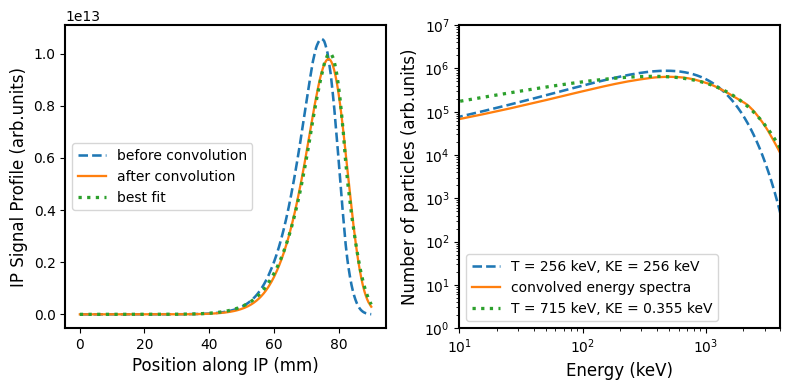

In [99]:
##derived energy spectra without deconvolution##

from scipy.signal import savgol_filter as sfilter
from scipy.optimize import curve_fit

# ##code for case 2##
# T = 6
# bulk_KE = 8
# Amplitude = 1e9
# ##End of code for case 2##

# ##code for case 2##
# T = 1
# bulk_KE = 24
# Amplitude = 1e9
# ##End of code for case 2##

# ##code for case 3##
# T = 8
# bulk_KE = 256
# Amplitude = 1e9
# ##End of code for case 3##

# ##code for case 4##
# T = 0.55
# bulk_KE = 0
# Amplitude = 1e9
# ##End of code for case 4##

# ##code for case 5##
# T = 128
# bulk_KE = 128
# Amplitude = 1e9
# ##End of code for case 5##

##code for case 6##
T = 256
bulk_KE = 256
Amplitude = 1e9
##End of code for case 6##

##loading case##
dNdE = rel_maxwell(((E_axis/1000)+(ratio*512.4376)),T,Bulk_Speed,Amplitude, particle = 'proton')
dSdx = np.load('ideal_spectra_T='+str(T)+'keV_KE='+str(bulk_KE)+'Amplitude='+str(Amplitude)+'.npy')
dSdx_ = np.load('convolved_spectra_T='+str(T)+'keV_KE='+str(bulk_KE)+'Amplitude='+str(Amplitude)+'.npy')
dSdN = TR_proton_PSL_scale(E_axis/1000)

dSdE_ = dSdx_*dxdE_x(x_axis)
dNdE_ = dSdE_/dSdN

dSdx_smoothed = sfilter(dSdx_,16,3)
dSdE_smoothed = dSdx_smoothed*dxdE_x(x_axis)
dNdE_smoothed = dSdE_smoothed/dSdN

##guess parameters for convolved plot##

# ##case 1##
# T = 6.8 #in keV
# bulk_KE = 8 #in keV
# Bulk_Speed = np.sqrt((2*bulk_KE*1000*1.602e-19)/(1.6726e-27))/(2.99792e8)
# print(Bulk_Speed)
# Amplitude = 0.91e9 #arbitrary

# ##case 2##
# T = 1.20 #in keV
# bulk_KE = 25.5 #in keV
# Bulk_Speed = np.sqrt((2*bulk_KE*1000*1.602e-19)/(1.6726e-27))/(2.99792e8)
# print(Bulk_Speed)
# Amplitude = 0.92e9 #arbitrary

# ##case 3##
# T = 10.5 #in keV
# bulk_KE = 141.25 #in keV
# Bulk_Speed = np.sqrt((2*bulk_KE*1000*1.602e-19)/(1.6726e-27))/(2.99792e8)
# print(Bulk_Speed)
# Amplitude = 0.875e9 #arbitrary

# ##case 4##
# T = 0.675 #in keV
# bulk_KE = 0.15 #in keV
# Bulk_Speed = -np.sqrt((2*bulk_KE*1000*1.602e-19)/(1.6726e-27))/(2.99792e8)
# print(Bulk_Speed)
# Amplitude = 1.05e9 #arbitrary

# ##code for case 5##
# T = 169
# bulk_KE = 108
# Bulk_Speed = np.sqrt((2*bulk_KE*1000*1.602e-19)/(1.6726e-27))/(2.99792e8)
# Amplitude = 0.865e9
# ##End of code for case 5##

##Inputting guessed maxwellian parameters into forward model, multiplying by scaling factors##
dNdE_guess = rel_maxwell(((E_axis/1000)+(ratio*512.4376)),T,Bulk_Speed,Amplitude, particle = 'proton')
dSdN = TR_proton_PSL_scale(E_axis/1000)

dSdE_guess = dNdE_guess*dSdN
dSdx_guess = dSdE_guess/dxdE_x(x_axis)

def fitting_function(x_axis,Temperature,KE,Amp):
    E_axis = Efromx(x_axis)
    Speed = np.sqrt((2*KE*1000*1.602e-19)/(1.6726e-27))/(2.99792e8)
    dNdE_guess_fit = rel_maxwell(((E_axis/1000)+(ratio*512.4376)),Temperature,Speed,Amp, particle = 'proton')
    dSdN_input = TR_proton_PSL_scale(E_axis/1000)
    dSdE_guess_fit = dNdE_guess_fit*dSdN_input
    dSdx_guess_fit = dSdE_guess_fit/dxdE_x(x_axis)
    return dSdx_guess_fit

dSdx_fitted_guess_params, param_cov = curve_fit(f=fitting_function,xdata=x_axis,ydata=dSdx_,p0=[T,bulk_KE,Amplitude])#bounds=([80,80,6e8],[250,250,1.4e9]))
print(dSdx_fitted_guess_params)
dSdx_fitted_guess = fitting_function(x_axis,dSdx_fitted_guess_params[0],dSdx_fitted_guess_params[1],dSdx_fitted_guess_params[2])
T_guess = dSdx_fitted_guess_params[0]
Bulk_KE_guess = dSdx_fitted_guess_params[1]
Bulk_Speed_guess = np.sqrt((2*Bulk_KE_guess*1000*1.602e-19)/(1.6726e-27))/(2.99792e8)
Amplitude_guess = dSdx_fitted_guess_params[2]

dNdE_fitted_guess = rel_maxwell(((E_axis/1000)+(ratio*512.4376)),T_guess,Bulk_Speed_guess,Amplitude_guess, particle = 'proton')

# chi = 20
# slit_function = gaussian(np.linspace(-2*chi,2*chi,4*chi),0,chi)
# length = 60
# slit_function = (1/length)*(np.ones(length+1)+np.linspace(-0.1,0.1,length+1))

#slit_function = np.ones(2)

#checking error bounds
percenterror = 5

extra_dNdE = rel_maxwell(((E_axis/1000)+(ratio*512.4376)),T_guess,Bulk_Speed_guess*(1+percenterror/100),Amplitude_guess*(1-3/100), particle = 'proton')
extra_dSdE = extra_dNdE*dSdN
extra_dSdx = extra_dSdE/dxdE_x(x_axis)

##plotting outputs for convolved image##

#fig, axs = plt.subplots(2, 1, figsize=(5.5, 8.25))
fig, axs = plt.subplots(1, 2, figsize=(8, 4))


axs[0].plot(x_axis[81:]*1e3, dSdx[81:], linestyle = '--', label = 'before convolution', linewidth = 1.85)
axs[0].plot(x_axis[81:]*1e3, dSdx_smoothed[81:], label = 'after convolution', linewidth = 1.65)
axs[0].plot(x_axis[81:]*1e3, dSdx_fitted_guess[81:],linestyle = ':', label = 'best fit', linewidth = 2.35)

#axs[0].plot(x_axis[81:]*1e3, extra_dSdx[81:], linestyle = '-.', label = 'extra', linewidth = 1.85)


axs[0].set_xlabel('Position along IP (mm)')
axs[0].set_ylabel('IP Signal Profile (arb.units)')
#axs[0].legend()
axs[0].legend(loc = 6)#128 128
# axs[0].legend(loc = 1)#6 8
# axs[0].legend(loc = 6)#8 256

axs[1].loglog(E_axis*1e-3, dNdE, linestyle = '--', label = 'T = '+str(T)+' keV, KE = '+str(bulk_KE)+' keV', linewidth = 1.85)
axs[1].loglog(E_axis*1e-3, dNdE_smoothed, label = 'convolved energy spectra', linewidth = 1.65)
axs[1].loglog(E_axis*1e-3, dNdE_fitted_guess, linestyle = ':', label = 'T = '+f"{T_guess:.3g}"+' keV, KE = '+f"{Bulk_KE_guess:.3g}"+' keV', linewidth = 2.35)


axs[1].set_ylim(1e0,1e7) #128 128
axs[1].set_xlim(1e4*1e-3,4e6*1e-3) #128 128
# axs[1].set_ylim(1e2,1e8) #6 8
# axs[1].set_xlim(1e2*1e-3,3e5*1e-3) #6 8
# axs[1].set_ylim(1e0,1e9) #8 256
# axs[1].set_xlim(1e4*1e-3,1.2e6*1e-3) #8 256
axs[1].set_ylabel('Number of particles (arb.units)')
axs[1].set_xlabel('Energy (keV)')
axs[1].legend()

for location in ['left', 'right', 'top', 'bottom']:
    axs[0].spines[location].set_linewidth(1.5)
    axs[1].spines[location].set_linewidth(1.5)

fig.tight_layout()
print(E_axis[80]*1e3)
print(dNdE_smoothed[80]/dNdE[80])

# energy_in = 2.5e5
# fraction = (np.interp(energy_in,E_axis,dNdE_))/(np.interp(energy_in,E_axis,dNdE))
# print(fraction)

Spectrometer Initialized!
[-7.10842167e-03 -7.02091301e-03 -6.93797387e-03 -6.85496832e-03
 -6.76701893e-03 -6.68424003e-03 -6.59561399e-03 -6.51311229e-03
 -6.43054503e-03 -6.34164292e-03 -6.25940343e-03 -6.16985023e-03
 -6.08799149e-03 -6.00606854e-03 -5.91591921e-03 -5.83446212e-03
 -5.75294149e-03 -5.66198021e-03 -5.58103723e-03 -5.48876972e-03
 -5.40851117e-03 -5.32819162e-03 -5.23550788e-03 -5.15597645e-03
 -5.06217164e-03 -4.98352486e-03 -4.90482084e-03 -4.81097264e-03
 -4.73324593e-03 -4.65546413e-03 -4.56178542e-03 -4.48506734e-03
 -4.39055729e-03 -4.31497993e-03 -4.23935250e-03 -4.14530485e-03
 -4.07089063e-03 -3.99642900e-03 -3.90296445e-03 -3.82977526e-03
 -3.75654141e-03 -3.66344895e-03 -3.59158271e-03 -3.51967441e-03
 -3.42683797e-03 -3.35639370e-03 -3.28591010e-03 -3.19353181e-03
 -3.12459599e-03 -3.05562463e-03 -2.96375996e-03 -2.89641696e-03
 -2.82904021e-03 -2.73769238e-03 -2.67201913e-03 -2.60631492e-03
 -2.51558032e-03 -2.45164360e-03 -2.38767869e-03 -2.29760890e-03

(-0.00810842166571242, 0.0010869927384548298)

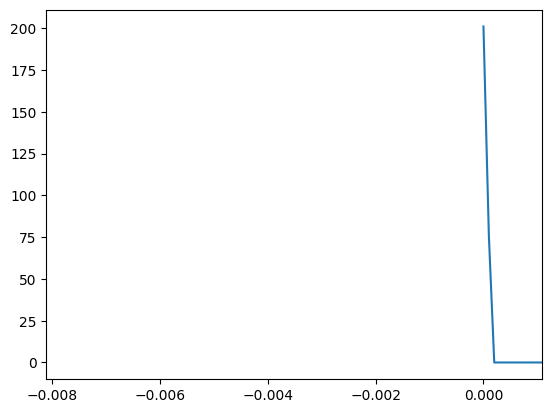

In [24]:
#>>initializing MagSpec
import matplotlib.ticker as ticker
import MagSpec
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.interpolate as spint

NEPPS_Field = (88.6/79)*np.loadtxt('Magnetic_Field_NEPPS.txt', skiprows=1)
Baxes, Bdata = NEPPS_Field[:,0], NEPPS_Field[:,1]
Spec = MagSpec.MagSpec()
Spec.mag_field(Baxes,Bdata)
Spec.fineadjustment(fine_adjustment = 8)
Spec.TCC(-0.2,0,0)
Spec.delta_d = 0.0002

Energy = 115
x_axis_params = [0,0.09,901]
x_axis = np.linspace(x_axis_params[0],x_axis_params[1],x_axis_params[2])
x_spacing = (x_axis_params[1]-x_axis_params[0])/(x_axis_params[2]-1)

#Spec.plotIP()

IP_dist_val, X_data, Y_data, Z_data = Spec.track_1D_slit(
        plotting = False,
        Energy_eV = Energy,
        source = 'point',
        Range = np.linspace(-0.0125,0.00125,101), 
        theta_z = 0,
        theta_0 = 0)

print(IP_dist_val)

interpolated_IP_dist_val = []
amplify_number = 100
particle_number_linspace = np.linspace(0,len(IP_dist_val)-1,len(IP_dist_val))
IP_dist_function = spint.CubicSpline(particle_number_linspace,IP_dist_val)
for i in range(len(IP_dist_val)):
    interpolated_IP_dist_val.append(IP_dist_val[i])
    if i != len(IP_dist_val)-1:
        dist_to_next_particle = IP_dist_val[i+1]-IP_dist_val[i]
        for j in range(1,amplify_number):
            interpolated_IP_dist_val.append(IP_dist_function(i+(1/amplify_number)*j))

#plt.plot(IP_dist_val)
#plt.plot(interpolated_IP_dist_val)
print(x_spacing)

slit_function_full_axis = np.zeros(len(x_axis))
for i in range(len(x_axis)):
    if np.min(IP_dist_val)-0.5*x_spacing < x_axis[i] < np.max(IP_dist_val)+0.5*x_spacing:
        IP_dist_a = np.array(interpolated_IP_dist_val)[np.where(np.array(interpolated_IP_dist_val)<(x_axis[i]+0.5*x_spacing))]
        #print(IP_dist_a)
        IP_dist_b = IP_dist_a[np.where(np.array(IP_dist_a)>(x_axis[i]-0.5*x_spacing))]
        #print(IP_dist_b)
        slit_function_full_axis[i] = len(IP_dist_b)

plt.plot(x_axis,slit_function_full_axis)
plt.xlim(np.min(IP_dist_val)-0.001,np.max(IP_dist_val)+0.001)
#plt.xlim(np.min(IP_dist_val),np.max(IP_dist_val))

# plt.plot(IP_dist_val)
# plt.xlim(15,100)
# plt.ylim(-0.0075,0.005)

(0.022100286191655584, 0.024742449146206127)

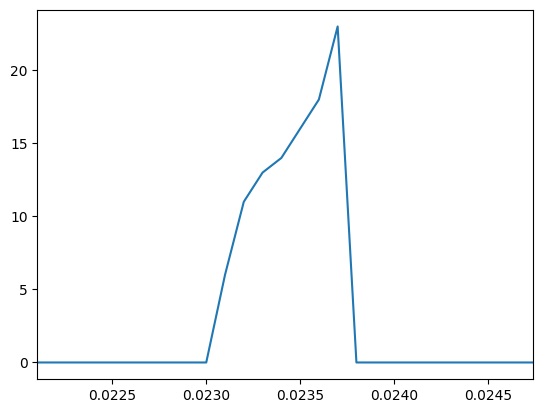

In [ ]:
#>>initializing MagSpec
import matplotlib.ticker as ticker
import MagSpec
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.interpolate as spint

x_axis_params = [0,0.09,901]
fine_splitting = 12
x_axis = np.linspace(x_axis_params[0],x_axis_params[1],x_axis_params[2])
x_spacing = (x_axis_params[1]-x_axis_params[0])/(x_axis_params[2]-1)
modified_x_axis = np.linspace(x_axis_params[0],x_axis_params[1],(fine_splitting*(x_axis_params[2]-1))+1)

E_axis = Efromx(x_axis)
modified_E_axis = Efromx(modified_x_axis)

#Energy = 500
#Energy = 2500
#Energy = 5000
#Energy = 7500
#Energy = 10000
Energy = 11000

IP_dist_val, X_data, Y_data, Z_data = Spec.track_1D_slit(
            plotting = False,
            Energy_eV = Energy,
            source = 'point',
            Range = np.linspace(-0.0125,0.00125,101), 
            theta_z = 0,
            theta_0 = 0)

interpolated_IP_dist_val = []
amplify_number = 1
particle_number_linspace = np.linspace(0,len(IP_dist_val)-1,len(IP_dist_val))
fine_particle_number_linspace = np.linspace(0,amplify_number*(len(IP_dist_val)-1),(amplify_number*(len(IP_dist_val)-1))+1)
IP_dist_function = spint.CubicSpline(particle_number_linspace,IP_dist_val)

print(fine_particle_number_linspace)

for i in range(len(fine_particle_number_linspace)):
    particle_number = fine_particle_number_linspace[i]
    interpolated_IP_dist_val.append(IP_dist_function(particle_number))

slit_function_full_axis = np.zeros(len(x_axis))

for i in range(len(x_axis)):
    if np.min(IP_dist_val)-0.5*x_spacing < x_axis[i] < np.max(IP_dist_val)+0.5*x_spacing:
        IP_dist_a = np.array(interpolated_IP_dist_val)[np.where(np.array(interpolated_IP_dist_val)<(x_axis[i]+0.5*x_spacing))]
        IP_dist_b = IP_dist_a[np.where(np.array(IP_dist_a)>(x_axis[i]-0.5*x_spacing))]
        slit_function_full_axis[i] = len(IP_dist_b)

slit_function_norm = (1/fine_splitting)*slit_function_full_axis/np.sum(slit_function_full_axis)

plt.plot(x_axis,slit_function_full_axis)
plt.xlim(np.min(IP_dist_val)-0.001,np.max(IP_dist_val)+0.001)

In [ ]:
##Cell for finding slit functions at each input position##

#>>initializing MagSpec
import matplotlib.ticker as ticker
import MagSpec
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.interpolate as spint

NEPPS_Field = (88.6/79)*np.loadtxt('Magnetic_Field_NEPPS.txt', skiprows=1)
Baxes, Bdata = NEPPS_Field[:,0], NEPPS_Field[:,1]
Spec = MagSpec.MagSpec()
Spec.mag_field(Baxes,Bdata)
Spec.fineadjustment(fine_adjustment = 8)
Spec.TCC(-0.2,0,0)
Spec.delta_d = 0.0001

##finding EXDispersion##
Espace_big = np.linspace(125, 10000125, 10000)
Xspace_big = Spec.EXdispersion(Espace_big, y_0 = 0, theta_0 = 0, track_termination=True)
plt.plot(Espace_big,Xspace_big)

##input your position space here##
x_space = np.linspace(0,1500,501)


Energy = 200

IP_dist_val, X_data, Y_data, Z_data = Spec.track_1D_slit(
    plotting = False,
    Energy_eV = Energy,
    source = 'point',
    Range = np.linspace(-0.002,0.002,51), 
    theta_z = 0,
    theta_0 = 0)

IP_linspace, Particle_Density, Particle_Density_a, Particle_Density_b = Spec.slit_function(IP_dist_val)
# plt.plot(IP_linspace*1000, Particle_Density, label = 'total slit function')
# #plt.plot(IP_linspace*1000, Particle_Density_a, linestyle = ':', label = 'inverted image')
# #plt.plot(IP_linspace*1000, Particle_Density_b, linestyle = '-.', label = 'non-inverted image')
# plt.xlim(1000*IP_linspace[0]-0.1,1000*IP_linspace[-1]+0.1)
# plt.rc('font',size=8)
# plt.legend()
# plt.xlabel('distance along IP (mm)')
# plt.ylabel('particles per unit distance')


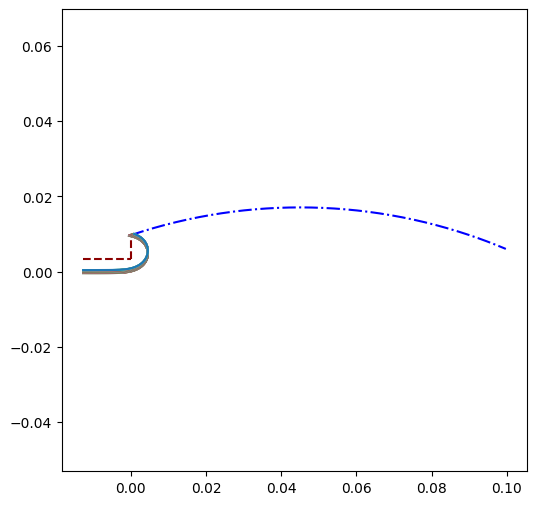

In [33]:
####

Spec.plotIP(figsize = [6,6])

#various energies to test
#Energy = 10000
#Energy = 5260
#Energy = 5000
#Energy = 5500
#Energy = 2000
Energy = 150

IP_dist_val, X_data, Y_data, Z_data = Spec.track_1D_slit(
    plotting = True,
    Energy_eV = Energy,
    source = 'point',
    Range = np.linspace(-0.002,0.002,51), 
    theta_z = 0,
    theta_0 = 0)

##start of code for plotting particle trajectories##

#zoom in!
xc = 0.015
yc = 0.014
w = 0.005
#plt.xlim(xc-w,xc+w)
#plt.ylim(yc-w,yc+w)
#print(Spec.TCC_x)

#better view of tracks
# plt.xlim(-0.005,0.030)
# plt.ylim(-0.005,0.030)
# plt.xlabel('x position (m)')
# plt.ylabel('y position (m)')
# SMALL_SIZE = 10
# MEDIUM_SIZE = 12
# BIGGER_SIZE = 10
# plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
# plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
# plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
# plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
# plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
# plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
# plt.legend()

##end of code for plotting particle trajectories##

##code for plotting slit function##

# IP_linspace, Particle_Density, Particle_Density_a, Particle_Density_b = Spec.slit_function_precise(IP_dist_val)
# plt.plot(IP_linspace*1000, Particle_Density, label = 'total slit function')
# plt.plot(IP_linspace*1000, Particle_Density_a, linestyle = ':', label = 'inverted image')
# plt.plot(IP_linspace*1000, Particle_Density_b, linestyle = '-.', label = 'non-inverted image')
# plt.xlim(1000*IP_linspace[0]-0.015,1000*IP_linspace[-1]+0.025)
# plt.ylim(0,0.2e6)
# plt.ylim(0,0.6e7)
# plt.rc('font',size=8)
# plt.legend()
# plt.xlabel('distance along IP (mm)')
# plt.ylabel('particles per unit distance')

#>>end of code for plotting slit function

#>>plotting x(E) and dxdE

# fig, ax1 = plt.subplots(figsize = [6,6])
# plt.rc('font', size=15)
# ax2 = ax1.twinx()
# Espace = np.append(np.linspace(140.97,140.97+1500,501),np.linspace(140.97+2000,10e6+140.97,2001))
# Xspace = Spec.EXdispersion(Espace)
# np.savetxt("Generated_Dispersion.txt", np.array([(1/1000)*Espace,1000*Xspace]), delimiter=",")
# ax1.plot((1/1000)*Espace,1000*Xspace, label = 'x(E)')

# #compare to Gennady's data
# energy_data_protons = np.loadtxt('NEPPS_Dispersion_Protons_087T.txt', skiprows=1)
# #plt.plot(energy_data_protons[:,0],energy_data_protons[:,1])
# #plt.plot(Espace,Xspace*10000)

# ax1.set_xlabel("Energy (keV)")
# ax1.set_ylabel("Distance Traveled Along IP (mm)")
# #plt.title(label = "x(E) Dispersion Relation at Normal Incidence", fontsize=12)
# dxdE = np.gradient(1000*Xspace,(1/1000)*Espace)
# ax2.plot((1/1000)*Espace,dxdE,label = 'dx/dE',color = 'red', linestyle = ':')
# ax2.set_ylabel('dx/dE (mm/keV)')
# ax2.set_ylim(-0.016,0.4)

# ax1.tick_params(axis = 'y', labelcolor = 'blue')
# ax2.tick_params(labelcolor = 'red')

# ax1.legend(bbox_to_anchor = (0.95,0.85), loc = 'right')
# ax2.legend(bbox_to_anchor = (0.95,0.15), loc = 'right')
#end of plotting e and dxdE


#plt.xlim(-0.5,-0.49)
#plt.ylim(-0.005,0.005)

#for slit function
#plt.xlim(0.0175,0.0177)
#plt.ylim(0,1e7)
#plt.xlabel("Position Along IP (m)")
#plt.ylabel("Particle Density (dN/dx)")
#plt.title("Slit Function at Energy " + str(Energy) + "eV")
#plt.legend()